<a href="https://colab.research.google.com/github/todd-jang/AIFFEL_quest_rs/blob/main/MainQuest/Quest04/GenAI-proposal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

last modified date : 2026.03  
제작 : 박광석 (모두의연구소)

#Score Based Model

우도 기반 모델인 VAE나 DDPM, 그리고 암묵적 생성 모델인 GAN은 각자 해결하기 어려운 숙제를 안고 있습니다. VAE 같은 모델은 데이터가 나타날 확률을 정확히 계산하기 위해 모델 구조를 아주 까다롭게 제한해야 하거나, 계산이 너무 복잡해서 실제 정답 대신 비슷한 가짜 목표를 세워 돌아가는 복잡한 방식을 써야만 합니다. 반면 GAN은 두 모델이 서로 경쟁하며 실력을 키우는데, 이 과정이 마치 줄타기를 하듯 매우 불안정해서 학습이 제대로 되지 않는 경우가 많습니다.  
  
이러한 제약 상황에서, 연구자들은 우리가 확률 분포 $p(x)$ 전체를 알 필요가 있을까? 우리가 있는 지점에서 '데이터가 더 많은 방향'만 알면 되지 않을까? 는 근본적인 질문을 던지게 되고, 확률 밀도 자체가 아닌 로그 확률 밀도 함수의 기울기 ((Stein) 점수 함수 라고도 함)를 모델링하여 제약을 극복하는 Score Matching개념이 등장하게 됩니다.  

Quiz : 위에 언급한 “확률 분포 $p(x)$ 전체를 알 필요가 있을까? 에 대해 연구자들은 ‘intractable 하다’ 라고 이야기합니다. Intractable 하다는 것이 어떤 내용인지 찾아볼까요?

Answer : 실제 데이터의 확률 분포를 정의할 때 필요한 '전체 합'을 계산하는 것이 수학적으로 너무 거대하여 불가능함을 의미합니다. VAE의 Posterior 설명을 떠올려보세요!

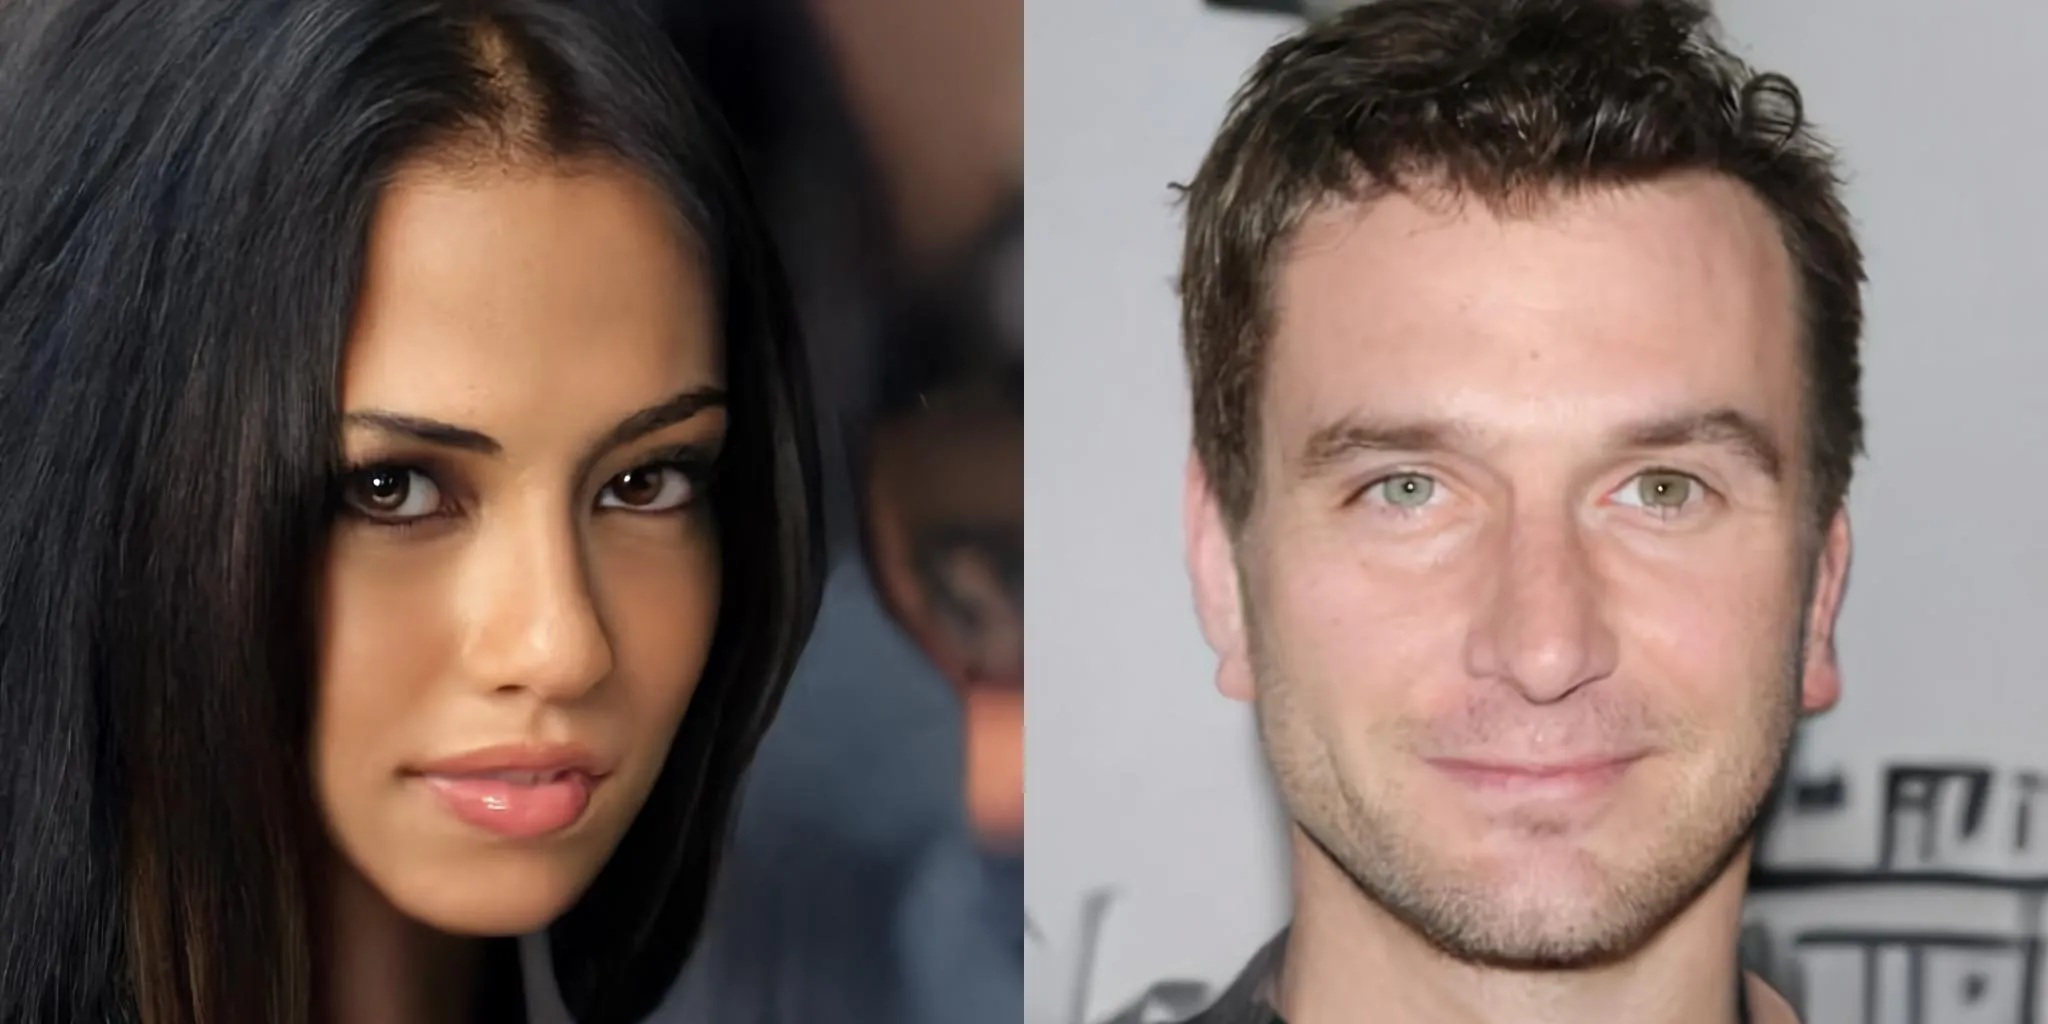

Score matching 으로 생성한 이미지입니다. 해상도도 크고, 감쪽같죠?

## 1. Score-Based Generative Model

Score-Based Generative Model(SGM)은 스코어 함수(score function) 를 직접 학습하여 샘플을 생성하는 확률 모델입니다.
  
주요 특징은 다음과 같습니다.

- **확산 없이도 정의되는 생성 원리**
    
    고차원 분포의 그라디언트 필드(기울기 지도)를 바로 추정하므로, 따로 잠재 변수를 설정하지 않습니다.
    
- **노이즈 레벨을 조건으로 도입한 Noise Conditional Score Network(NCSN)**
    
    데이터가 없는 영역에서도 길을 찾을 수 있도록 여러 단계의 스코어를 합성하여 전체 밀도를 안정적으로 근사합니다.
    
- **역확산 → ODE / SDE**
    
    스코어 함수만 안다면 미분 방정식(ODE/SDE)을 통해 무작위 상태에서 데이터를 복원하고 생성할 수 있습니다.
    

이 모델 계열은 이후 **Score SDE(2021)**·**ODE 기반 빠른 샘플러**·**UniPC(2023)** 등으로 진화하여, 현존 최고 수준의 이미지·음향·3D 샘플 품질을 달성하고 있습니다.

## 1.1 “스코어(score)”란 무엇인가?

안개 낀 산 위에서 조난당했다고 가정합시다. 지도는 없지만, 발밑의 경사를 느껴 '더 높은 곳'으로 한 발자국씩 옮기면 결국 정상에 도착할 것입니다. 이때 '더 높은 곳(데이터 밀도가 높은 곳)'을 가리키는 화살표가 바로 스코어입니다.  
즉, 어떤 지점 $\mathbf x$ 에서 “데이터가 많은 방향” 을 알려 주는 화살표입니다. 수학적으로 스코어 함수는 로그 우도(log likelihood)의 기울기로 정의됩니다.

$$\text{score}(\mathbf x)=
\nabla_{\!\mathbf x}\,
\log p(\mathbf x)$$

종 모양(정규분포)을 생각해 봅시다.

- 가운데(평균값)로 갈수록 확률이 높습니다.
- 좌우 끝에서는 화살표가 “중앙 쪽”으로 향합니다.
- 가운데에서는 더 이상 올라갈 곳이 없으니 화살표 길이가 0입니다.

이게 바로 데이터를 향한 이정표,  “스코어 필드(score field)”입니다.

1. **데이터 위치가 어디든** 간에, 스코어를 이용하면 *“어디로 가야 확률이 커지는지”*를 알 수 있습니다.
2. 그러면 **빈 캔버스(무작위 노이즈)** 에도 스코어를 반복 적용해 *거꾸로* 내려오면,
    
    **결국 데이터 분포에 도달**할 수 있습니다.
    

한마디로 “산(확률 지형) 꼭대기를 알려 주는 나침반” 을 먼저 학습한 뒤, 그 나침반을 따라 정상으로 올라가는(=샘플을 만들어 내는) 방식입니다.

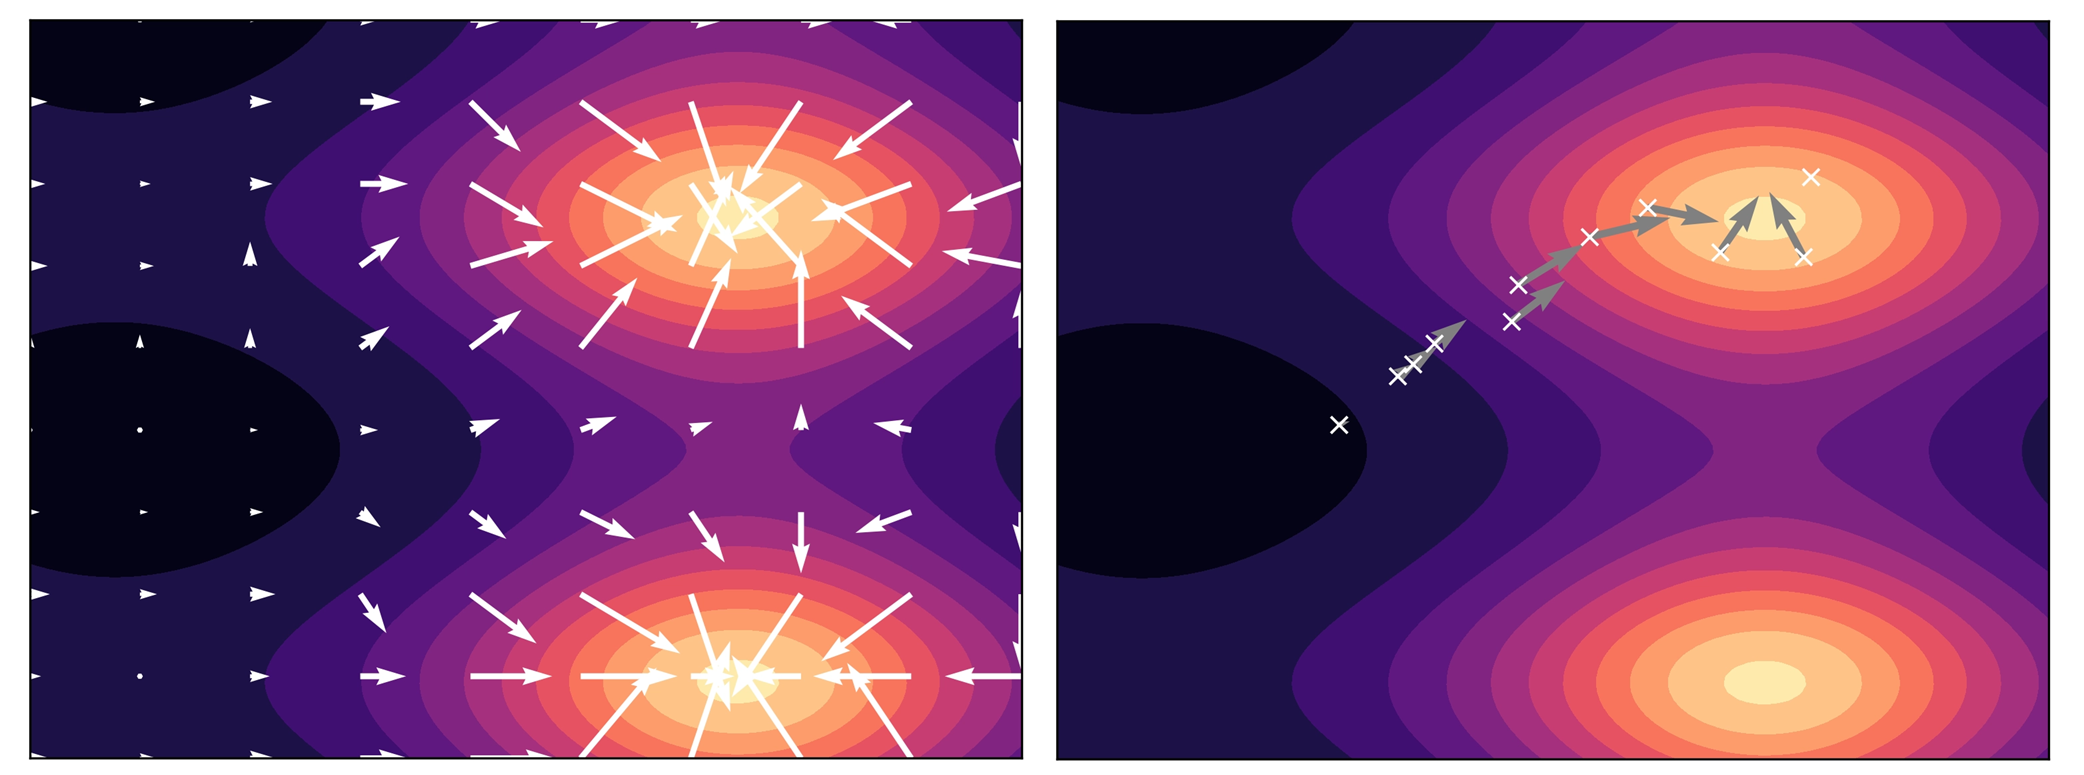

다음 그림의 왼쪽은 Score field, Score function $s( x )$ 의 기울기를 화살표로 방향과 크기를 표시한 것입니다. 어두운 색상은 낮은 확률을 나타내고 밝은 색상은 높은 확률을 나타냅니다. 오른쪽은 이 기울기를 따라 한 발자국씩 옮기는 과정을 적용한 후의 궤적으로, 연속된 점은 흰색 십자가로 표시하고 점수는 회색 화살표로 표시하였습니다.

NCSN(Noise Conditional Score Network) 에서 저자는 딥러닝 모델을 사용하여, 어떤 지점($x$)을 찔러넣든 그곳에서의 정답 화살표($s(x)$)를 즉석에서 계산해주도록 합니다.

- 입력: 현재 위치한 데이터 지점 $x$ (그리고 뒤에서 배울 노이즈의 세기 $\sigma$).
- 출력: 그 지점에서 "데이터 밀도가 높아지는 방향"을 가리키는 스코어 벡터(Score Vector).

즉, 이 모델은 이미지의 픽셀 하나하나를 '생성'하는 법을 직접 배우는 것이 아니라, 픽셀들이 어느 방향으로 움직여야 더 진짜 같은 데이터($P_{data}$)가 되는지 그 '길잡이' 역할을 수행하도록 학습됩니다.

### 1.2 목표 설정 : Fisher Divergence

앞서 우리는 Score가 "데이터가 많은 쪽을 가리키는 화살표"라고 했습니다. 그렇다면 AI 모델인 $s_\theta(\mathbf{x})$가 이 화살표를 얼마나 잘 그리는지 평가할 '채점표'가 필요합니다. 그게 바로 Fisher Divergence입니다.

$$ J(\theta) = \mathbb{E}{p(\mathbf{x})} \left[ \frac{1}{2} \| \nabla{\mathbf{x}} \log p(\mathbf{x}) - s_\theta(\mathbf{x}) \|_2^2 \right] $$

그동안 봐오셨던 MSE와 같은 꼴이죠? Term을 하나씩 살펴보겠습니다.

**$J(\theta)$**: 손실 함수 값입니다. 이 값이 **0에 가까워질수록** 우리 모델은 실제 데이터의 스코어를 완벽하게 베낀 '황금 나침반'이 됩니다.   
**$\mathbb{E}_{p(\mathbf{x})}$**: "평균적으로"라는 뜻입니다. 특정 사진 한 장만 잘 맞추는 게 아니라, 우리가 가진 모든 데이터($p(\mathbf{x})$)에 대해서 골고루 잘 맞추도록 평균을 내서 계산합니다.   
**$\frac{1}{2} \| \nabla{\mathbf{x}} \log p(\mathbf{x}) - s_\theta(\mathbf{x}) \|_2^2$**: 오차의 제곱입니다. 진짜 정답 방향과 우리 모델이 가리키는 방향이 다르면 그 차이를 제곱해서 벌점을 줍니다.  (제곱을 하는 이유는 계산의 편의성과 큰 오차에 더 엄격한 벌점을 주기 위해서입니다.)

### 1.3 학습 방법 : Score Matching

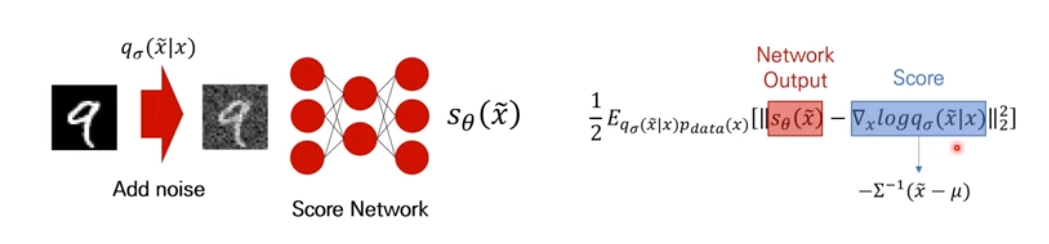

[[https://hyunseo-fullstackdiary.tistory.com/428](https://hyunseo-fullstackdiary.tistory.com/428)]

이 ‘채점표’를 이용하여 Score network를 학습시킵니다. 이 과정은 마치 **길을 잃게 만든 뒤, 집으로 돌아오는 법을 가르치는 것**과 같습니다.

1.  **Noise Injection**
    ◦ 단순히 깨끗한 데이터만 보여주는 것이 아니라, 데이터  $ \mathbf{x}$ 에 다양한 세기의 노이즈를 섞어 **"일부러 길을 잃게"** 만듭니다.
    ◦ 모델($s_\theta$)은 이렇게 노이즈가 섞인 지점에서 **"다시 데이터가 밀집된 곳으로 돌아가려면 어느 방향으로 가야 하는가?"**를 예측하여 화살표를 그립니다.
    ◦ 이때 주입되는 노이즈는 모델이 데이터가 없는 영역(Low-density region)에서도 당황하지 않고 스코어를 계산할 수 있게 만드는 **'훈련용 안개'** 역할을 합니다.

2. **채점** :
    ◦ 앞서 설명한 Fisher Divergence $J(\theta)$ 을 통해 모델이 그린 화살표와 **'진짜 돌아가야 할 정답 방향'** 사이의 거리(오차)를 잽니다.
    ◦ 노이즈를 얼마나 섞었는지 우리가 알고 있다면 진짜 스코어를 몰라도 이 오차를 계산할 수 있는 **Denoising Score Matching** 기법을 사용합니다. DDPM에서 썼던 그 방법입니다!

3. **Optimization** :
    ◦모델이 그린 화살표가 우리가 알고 있는 '복원 방향'과 일치하도록 $\theta$를 경사하강법을 통해 업데이트 합니다.이 과정을 반복하면, 모델은 직접 가본 적 없는 영역에서도 "아, 이 정도 노이즈가 섞였을 땐 이쪽이 데이터가 있는 방향이야"라고 판단할 수 있는 능력을 갖추게 됩니다.

    ◦ 이 과정을 반복하면 모델은 어떤 노이즈 섞인 상태에서도 "집(데이터)으로 가는 방향"을 정확히 가리키는 황금 나침반이 됩니다.

### 1.4. Inference : Langevin dynamics

앞서 우리는 데이터의 로그 확률 밀도($\log p(x)$)의 기울기를 모사하는 score function, 그리고 그 기울기를 정확히 추정해 내는 역할을 하는 네트워크를 훈련해내었습니다. 이제 확보한 스코어 함수(Score function) $\nabla_{\!\mathbf x} \log p(\mathbf x)$ 를 길잡이 삼아 무작위 노이즈로부터 데이터를 복원해낼 차례입니다.

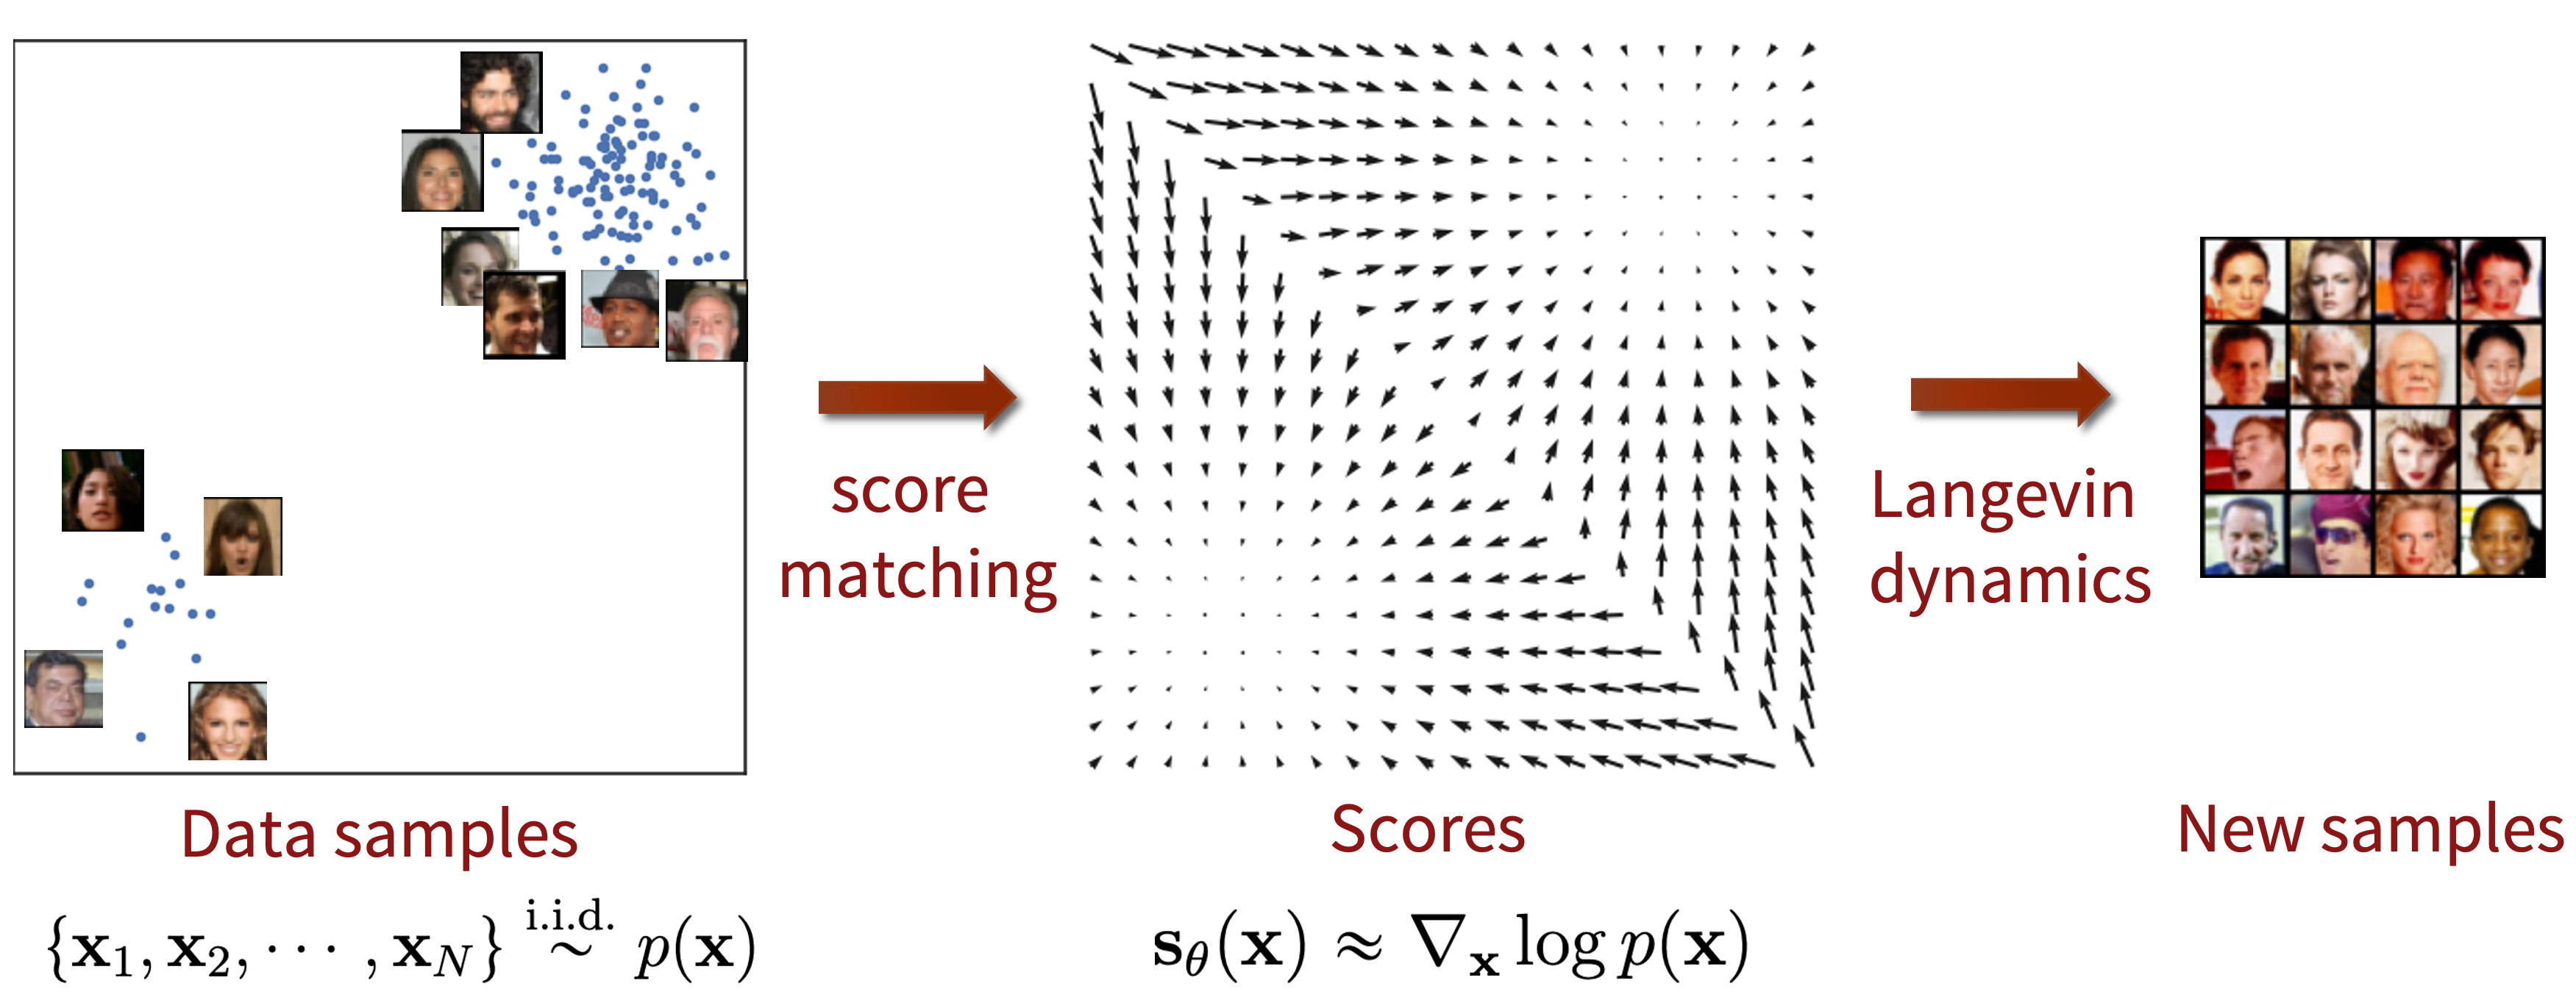

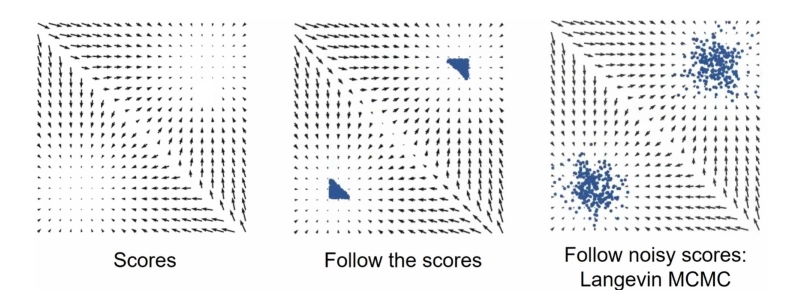

<[https://sadegh-aa.github.io/projects/aliakbarian_energy_models_note_2025.pdf](https://sadegh-aa.github.io/projects/aliakbarian_energy_models_note_2025.pdf)>

위 그림은 우리가 학습한 스코어를 따라 데이터를 생성할 때, 노이즈 주입 여부에 따라 결과가 어떻게 달라지는지 보여줍니다.

- **Scores (왼쪽):** 모델이 학습한 스코어 필드입니다. 화살표는 확률이 높은 곳을 향하고 있습니다.
- **Follow the scores (가운데):** 무작위 노이즈 없이 오직 스코어(기울기)만 따라갔을 때의 모습입니다. 샘플들이 가장 가까운 꼭대기(Local Minima)에 갇혀버려 데이터의 전체적인 분포를 표현하지 못하고 뭉쳐 있는 것을 볼 수 있습니다.
- **Follow noisy scores: Langevin MCMC (오른쪽):** 스코어에 적절한 노이즈를 섞어 이동한 결과입니다. 샘플들이 확률 지형을 충분히 탐색하며 실제 데이터의 밀도와 분포를 정확하게 재현해냅니다.

다음은 데이터를 샘플링(Sampling)할 때 사용하는 핵심 알고리즘, Langevin dynamics 입니다.

$$x_{t+1} = x_t + \epsilon \nabla_x \log p_\theta(x) + \sqrt{2\epsilon} z^t, \quad z^t \sim \mathcal{N}(0, I)$$

 수식의 각 항(Term)을 하나씩 해부해보겠습니다.  
 $x_t$ (현재 상태): 샘플링 과정의 현재 지점입니다. 처음에는 형체 없는 무작위 노이즈에서 시작하여 점차 구체적인 데이터의 모습으로 변해갑니다.

$\epsilon \nabla_x \log p_\theta(x)$ (기울기를 따르는 이동): 우리가 학습한 스코어(Score)입니다. 데이터 밀도가 높은 방향(High-density region)을 찾아 이동하게 만들며, 샘플이 실제 데이터와 유사한 특징을 갖추도록 유도합니다.

$\sqrt{2\epsilon} z^t$ (무작위 탐색): 매 스텝마다 주입되는 무작위 노이즈입니다. 단순히 가장 가까운 고득점 지점으로만 수렴하는 것이 아니라, 주변 공간을 적절히 탐색(Exploration)하며 샘플의 다양성을 확보하고 지역 최적점(Local Optima)에 갇히지 않게 돕습니다.

Score Matching에 대한 수학적인 풀이 및 자세한 내용은 NCSM 및 아래 소개될 SDE & ODE의 저자 Yang song의 블로그에 잘 설명이 되어있습니다.

https://yang-song.net/blog/2021/score/

### 1.5 한계와 고도화

우리가 학습한 스코어 함수를 따라가는 Langevin Dynamics는 이론적으로 완벽해 보이지만, 실제 데이터에서는 치명적인 문제에 직면합니다. 실제 데이터 분포는 매우 좁은 영역에만 밀집되어 있어, 그 외의 영역(Low-density)에서는 스코어 함수가 제대로 학습되지 않습니다. 이 때문에 초기 무작위 노이즈 지점이 데이터 산맥과 너무 멀리 떨어져 있으면, 나침반(Score)이 엉뚱한 방향을 가리켜 정상으로 돌아오지 못하는 현상이 발생합니다.



**Annealed Langevin Dynamics: "안개를 단계별로 걷어내기"**  
이 문제를 해결하기 위해 NCSN(Noise Conditional Score Network)의 저자 양송(Yang Song)은 여러 세기의 노이즈 $\sigma$ 를 조건으로 학습하는 방식을 제안했습니다.

- 처음에는 아주 짙은 안개(강한 노이즈)를 뿌려 데이터의 대략적인 형태를 잡고, 점차 안개를 걷어내며(낮은 노이즈) 세밀한 디테일을 찾아가는 방식입니다.
- 이를 통해 모델은 데이터가 없는 텅 빈 공간에서도 길을 찾아 산 정상으로 복귀할 수 있게 되었습니다.

**그럼에도 남은 숙제: "끊어지는 계단"**  
하지만 Annealed 방식 역시 '얼마나 많은 단계의 노이즈를 설정할 것인가?'라는 하이퍼파라미터 문제에서 자유롭지 못했습니다. 노이즈 레벨이 이산적(Discrete)으로 끊어져 있다 보니, 그 사이의 변화를 완벽하게 포착하기 어렵다는 한계가 여전히 존재했죠. 이 때, 저자들은 "노이즈 레벨을 10개, 100개로 나누지 말고 **무한히 연속적**으로 만들면 어떨까?" 라는 아이디어를 가지게 됩니다. 이 질문이 바로 이산적인 단계를 넘어 '강물 같은 흐름'을 다루는 **SDE(확률 미분 방정식)** 기반 생성 모델이 탄생하게 된 배경입니다.

### 1.6. "연속적 흐름"을 구현하기 위한 두 가지 열쇠

1.5에서 던진 "무한히 연속적으로 만들면 어떨까?"라는 질문에 답하기 위해, 연구자들은 당시 딥러닝 학계의 혁신적인 두 도구를 결합했습니다.  

**Neural ODE**  

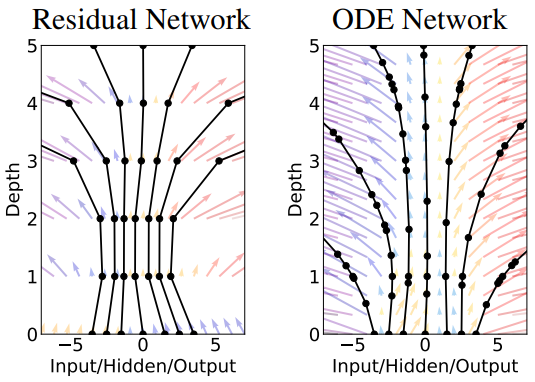

우리가 흔히 쓰는 잔차 연결(Residual Connection, ResNet)의 수식을 다시 떠올려 봅시다.

$$h_{t+1} = h_t + f(h_t, \theta_t)$$

여기서 $h_t$는 $t$번째 레이어의 출력값이고, $f$는 우리가 설계한 신경망입니다. 다음 층으로 갈 때 현재 값에 무언가($f$)를 조금 더해서 업데이트하는 방식이죠. 이건 마치 한 칸 한 칸 높이가 정해진 계단을 밟고 올라가는 것과 같습니다.

만약 우리가 이 레이어를 아주 얇게, 무한히 많이 쌓는다면 어떻게 될까요? 레이어 사이의 간격을 극도로 줄여서 '0'에 가깝게 만든다면, 위 식은 다음과 같이 변합니다.

$$\frac{h(t + \Delta t) - h(t)}{\Delta t} = f(h(t), t, \theta)$$

이 식을 $\Delta t \to 0$인 극한으로 보내면, 고등학교 수학 시간에 배웠던 미분의 정의가 나타납니다.

$$ \frac{dh(t)}{dt} = f(h(t), t, \theta) $$

이제 신경망 $f$는 "다음 층의 값"을 내뱉는 함수가 아니라, "현재 위치에서 데이터가 흘러갈 방향(기울기)"을 알려주는 함수가 됩니다. 그렇게 되면,  레이어 또한 1층, 2층이라는 '층'의 개념 대신, 시간 $t$가 흐름에 따라 변화하는 데이터의 궤적(Trajectory)' 을 구조에 담는다고 할 수 있습니다.  

**입력 데이터**: $t=0$일 때의 시작점  

**모델 학습**: 데이터가 우리가 원하는 목적지($t=T$)에 정확히 도착할 수 있도록 미끄럼틀의 곡률(신경망 $f$)을 조절하는 과정  

**출력 데이터**: 미분 방정식 풀이 도구(ODE Solver)를 이용해 미끄럼틀을 끝까지 타고 내려온 최종 결과물  

이 되는 것입니다!

이로 인해, 위 Annealed Langevin Dynamics에서 고민했던 "노이즈를 몇 단계로 나눌 것인가?"라는 질문은 이제 무의미해집니다. Neural ODE의 관점을 도입하면, 노이즈가 섞이는 과정을 **시간 $t$에 따른 연속적인 풍화 작용**으로 정의할 수 있기 때문입니다. 덕분에 우리는 1,000번의 불연속적인 스텝을 밟는 대신, **미분 방정식이라는 매끄러운 고속도로**를 타고 노이즈에서 데이터로, 혹은 데이터에서 노이즈로 자유롭게 이동할 수 있는 수학적 토대를 갖게 되었습니다.

**Normalizing Flow :  모양은 변해도 양은 변하지 않는다**

단순한 분포(찰흙 공) $z$를 복잡한 데이터(조각상) $x$로 바꾸는 함수를 $x = f(z)$라고 합시다. 이때 조각상 $x$가 나타날 확률 $p(x)$를 구하는 마법의 식은 다음과 같습니다.



$$p(x) = p(z) \cdot \left| \det \left( \frac{\partial f^{-1}}{\partial x} \right) \right|$$

- **$p(x)$**: 우리가 알고 싶은 최종 데이터의 확률입니다.  
- **$p(z)$**: 원래의 단순한 확률(예: 표준 정규 분포)입니다.    
- **$\left| \det \left( \frac{\partial f^{-1}}{\partial x} \right) \right|$ (야코비안 행렬식)**: 공간이 얼마나 늘어나거나 줄어들었는지를 나타내는 **'보정 계수'** 입니다. 찰흙을 얇게 펴서 면적이 넓어졌다면 밀도($p$)를 낮춰주고, 꾹 뭉쳤다면 밀도를 높여주는 역할을 하죠.

위 수식에서 $f^{-1}$이 등장하는 것에 주목해야 합니다. 데이터 $x$의 확률을 계산하려면, 이 조각상이 원래 어떤 찰흙 공($z$)이었는지 되돌아가는 길($f^{-1}$)을 반드시 알아야 합니다.  
- 1:1 대응: 데이터 하나당 노이즈 하나가 완벽하게 매칭되어야 정보가 새나가지 않습니다.  
- 손쉬운 생성: 학습이 끝나면, 그저 단순한 분포 $p(z)$에서 샘플 하나를 뽑아 $x = f(z)$에 넣기만 하면 고품질의 데이터가 툭 튀어나옵니다.

이제 앞서 확인한 Neural ODE를 여기에 얹어봅시다. 전통적인 NF는 함수 $f_1, f_2, f_3 \dots$를 징검다리처럼 건너며 확률을 계산했습니다. 하지만 Neural ODE를 만나면 이 과정이 시간 $t$에 따른 연속적인 흐름으로 변합니다.  
이산형 NF가 보정값들을 계속 곱했다면, **연속형 NF (CNF)**는 확률의 변화를 곱셈이 아닌 **적분($\int$)**으로 한꺼번에 계산합니다.

$$\log p(x(T)) = \log p(x(0)) - \int_{0}^{T} \text{Tr} \left( \frac{\partial f}{\partial x(t)} \right) dt$$

이 수식은 "시간 $t$ 동안 미끄럼틀을 타고 내려올 때, 확률이 조금씩 어떻게 변했는지 다 더해라"라는 뜻입니다. 덕분에 훨씬 더 복잡하고 자유로운 형태의 미끄럼틀(모델)을 설계할 수 있게 됩니다.

## 2. SDE & ODE

우리는 앞에서 DDPM이 이미지를 조금씩 오염시키고 복원하는 과정을 배웠고 , Score Matching을 통해 데이터의 산맥을 찾아가는 '나침반'을 얻었습니다.  한동안 생성모델의 큰 축이었던 두 방식은 ‘노이즈를 뿌리고 걷어낸다'는 같은 철학을 공유함에도 불구하고 다른 수식과 최적화 방식을 사용하고 있었습니다. 그리고 두 모델은 실전 적용에서 각각 다음과 같은 명확한 한계를 보였습니다.  
- DDPM의 느린 속도
마르코프 체인을 따라 단계적으로 노이즈 제거하는 방식의 DDPM의 경우, 정해진 1,000개의 계단을 하나하나 다 밟아야만 이미지가 완성되기 때문에 생성 속도가 너무 느리다는 단점이 있습니다.
- NCSN의 불안정한 경로
여러 강도의 노이즈를 섞어가며 학습하는 Score Matching 기반 모델은 노이즈 레벨 사이의 간격이 멀어지면 데이터가 없는 '진공 상태'에서 길을 잃거나, 특정 지점에 갇혀버리는(Local Minima) 문제가 발생했습니다.이의 간격이 멀면 데이터가 없는 곳에서 길을 잃거나 국소적인 지점에 갇히는 문제가 있습니다.

두 모델이 겪는 문제의 근본적인 원인은 **시간과 노이즈 레벨이 이산적(Discrete)으로 설정**되어 있다는 데 있습니다. 지금까지의 모델들은 시간을 $t = 1, 2, \dots, 1000$ 처럼 뚝뚝 끊어지는 숫자로 다루었습니다.
이러한 **"끊어지는 계단"** 방식은 마치 영화를 초당 1프레임으로 끊어 보는 것과 같습니다. 프레임 사이사이에 존재할 수 있는 미세한 변화를 포착하지 못하기 때문에, 계단 사이를 건너뛰려 하면 품질이 급격히 떨어지고(DDPM), 계단이 너무 높으면 발을 헛디디게(NCSN) 되는 것이죠.

이에 “노이즈 레벨을 무한히 촘촘하게 이어 붙여, **매끄러운 곡선(Continuous)** 으로 만들어보자”. 는 아이디어가 바로 확률 미분 방정식(**SDE**)과 상미분 방정식(**ODE**)을 생성 모델에 도입하게 된 계기입니다.  노이즈 스케일의 개수를 무한대로 일반화하여 연속적인 시간 축($t \in [0, T]$)으로 확장하면 다음과 같은 강력한 이점을 얻게 됩니다.  
- **샘플 품질의 극대화:** 이산적 단계에서 발생하는 이송 오차(Discretization error)를 최소화하여 훨씬 더 정교하고 사실적인 이미지를 생성합니다.
- **정확한 로그 우도(Log-likelihood) 계산:** 확률 흐름(Probability Flow)을 결정론적 ODE로 변환함으로써, 근사치가 아닌 데이터의 실제 확률 밀도를 정밀하게 추정할 수 있습니다.
- **제어 가능한 생성과 역문제(Inverse Problem) 해결:** '완전한 노이즈(관측된 결과)'로부터 '원본의 깨끗한 이미지(원인)'를 추론해내는 역과정을 수학적으로 통제할 수 있게 되어, 인페인팅이나 초해상도 같은 복잡한 작업들을 '원하는 조건'에 맞춰 수행할 수 있습니다.

### 2.1. SDE: 노이즈의 바다와 데이터의 대륙을 관통하는 생성의 통로

Score-based SDE 프레임워크는 데이터에 노이즈가 스며드는 과정을 '시간 $t$에 따른 미세한 변화량'으로 기술합니다 . 이를 수학적으로 표현한 기본 식은 다음과 같습니다.

$$dx = f(x, t)dt + g(t)dw$$

각 항의 의미를 해부해보겠습니다.

**$f(x, t)$ (Drift Coefficient, 드리프트 계수):** 시간에 따라 데이터 $x$ 가 특정 방향으로 흘러가는 '경향성'을 결정합니다. 이는 시스템의 결정론적인 부분을 담당하며, 데이터의 스케일을 조절하거나 중심(Origin)으로 끌어당기는 역할을 합니다.

**$g(t)$ (Diffusion Coefficient, 확산 계수):** 주입되는 노이즈의 '강도'를 조절합니다. $t$ 가 커질수록(즉, 시간이 흐를수록) 얼마나 강하게 데이터를 흩뜨릴지를 결정하는 계수입니다.

**$dw$ (Wiener process, 위너 프로세스):** 브라운 운동(Brownian Motion)을 수학적으로 정의한 것으로, 매 순간 주입되는 무작위 노이즈의 원천입니다. 아주 짧은 찰나($dt$) 동안 발생하는 무작위 변화량($dw$)은 평균이 0이고 분산이 $dt$ 인 가우시안 분포를 따릅니다.

위의 식이 노이즈가 섞이는 물리적 규칙을 정한 것이었다면, 그 규칙을 따라갔을 때 도착하는 "노이즈의 좌표”가 필요합니다. 딥러닝 모델을 학습 시키려면 ‘정답’이 필요하기 때문이죠! 여기에선 앞서 설명했듯, Denoising Score Matching을 하려면 깨끗한 이미지 $x_0$가 시간 $t$만큼 흘렀을 때 어떤 분포 $p_t(x|x_0)$를 갖는지 알아야 합니다.

### 2.2 퍼터베이션 커널(Perturbation Kernel): SDE를 학습 가능하게 만드는 다리

퍼터베이션 커널(Perturbation Kernel)이란 **쉽게 말해 노이즈가 섞인 결과물'** 을 뜻합니다.
생소한 term이지만 이 기점으로 많이 나오게 될 단어입니다.  

- **Perturbation** : 깨끗한 데이터 $x_0$를 노이즈로 흔들어 놓는 행위입니다.
- **Kernel(커널)**: 수학적으로는 $x_0$ 라는 입력이 $t$ 라는 시간을 거친 뒤, 어떤 $x_t$가 되어있을 확률을 계산해 주는 함수입니다. 즉, "내가 지금 $x_0$ 라는 사진을 들고 SDE라는 노이즈 터널에 들어갔을 때, $t$초 뒤에 내 손에 들려있을 이미지는 어떤 모습일까?"에 대한 확률적 답안지입니다.

SDE(특히 선형 SDE)의 가장 강력한 특징은 아무리 복잡해 보여도 $x_0$ 에서 $x_t$ 로 가는 전이 확률 분포, 즉 **퍼터베이션 커널 $p_{0t}(x_t | x_0)$ 이 항상 정규분포(Gaussian) 형태**를 띤다는 점입니다. 이 '가우시안의 마법'은 우리에게 두 가지 거대한 이점을 선사합니다.

- **수만 번의 시뮬레이션을 건너뛰는 '단번의 점프'**
    
    기존 DDPM은 1,000개의 계단이라는 이산적인 단계(Step)를 하나씩 밟아야만 했습니다 . 하지만 가우시안 커널 덕분에 우리는 수만 번의 미세한 노이즈 주입 과정을 거치지 않고도, $x_0$ 에서 우리가 원하는 어떤 시간 $t$ 의 노이즈 상태 $x_t$ 로 단번에 점프(Closed-form)해서 샘플을 만들 수 있습니다 .
- **스코어와 노이즈의 연결: "동전의 양면"**
    
    이 가우시안 커널이 대단한 진짜 이유는, 어떤 시간 $t$ 에서든 신경망이 내놓은 화살표가 맞았는지 틀렸는지 가려낼 **수학적으로 완벽한 정답**을 우리가 이미 알고 있는 '노이즈'를 통해 실시간으로 계산해낼 수 있기 때문입니다.
    
    가우시안 퍼터베이션 커널 $p_{0_{t}}(x_t|x_0) = \mathcal{N}(x_t; \mu_t, \sigma_t^2 I)$의 로그 기울기, 즉 스코어를 구해보면 다음과 같은 관계식이 도출됩니다 .

    $$\nabla_{x_t} \log p_{0t}(x_t | x_0) = \nabla_{x_t} \left( -\frac{\|x_t - \mu_t\|^2}{2\sigma_t^2} + C \right) = -\frac{x_t - \mu_t}{\sigma_t^2}$$  
    
    우리는 사실 데이터 분포가 어떻게 생겼는지 모르기 때문에, 그 복잡한 기울기인 스코어를 직접 구할 방법이 없었습니다. 하지만 우리가 직접 노이즈를 섞어 만든 데이터라면 이야기가 달라집니다. "어떤 이미지 $x_0$ 에 노이즈 $\epsilon$ 를 얼마나 섞었는지”는 우리가 실험실에서 직접 정한 정답(Label) 이기 때문에 아주 잘 알게 됩니다. 결국 Day 2에서 배웠던 DDPM이 '노이즈($\epsilon$)'를 예측하도록 학습했던 행위는 , 알고 보면 가장 계산하기 쉬운 노이즈를 빌려와서, 실제로는 가장 계산하기 어려운 스코어를 간접적으로 학습시키고 있었던 것입니다.

    이 수식 덕분에 **"노이즈를 잘 제거하는 것(DDPM)"** 과 **"데이터의 산맥을 찾아가는 나침반을 만드는 것(SDE/Score Model)"** 은 결국 같은 목표를 향한 하나의 기술로 통합됩니다.


이 지점에서 SDE는 기존 모델들의 한계를 우아하게 극복합니다. 기존 DDPM은 1,000개의 계단이라는 이산적인 시점에서만 정답을 정의할 수 있었지만, SDE는 가우시안 커널을 통해 0초부터 1초 사이의 어떤 찰나($t$)에서도 정확한 노이즈 좌표와 스코어를 정답지로 제공합니다. 또한 데이터가 없는 곳(Low-density)에서 길을 잃던 기존 스코어 모델과 달리, SDE는 아무리 멀리 떨어진 노이즈 영역이라도 **"저 멀리 데이터 산맥($x_0$)이 있는 방향"** 을 가리키는 정교한 수식을 즉석에서 찍어냅니다 .


결국 모델 $s_\theta(x, t)$는 모든 시간 $t \in [0, T]$에 대해 "이 시점에서 노이즈가 섞인 $x_t$를 보고, 원래 $x_0$가 어디 있었는지"를 추론하며 학습하게 됩니다. 복잡한 시뮬레이션 없이 '평균과 분산'이라는 간단한 숫자 두 개만으로 정답지를 만들어낼 수 있으니, 학습 속도와 정확도가 비약적으로 상승하게 되는 것입니다

수학적 의의가 더 궁금하신 분들은 다음의 링크를 참조바랍니다

https://janghan-kor.tistory.com/1855

### 2.3. SDE의 두 갈래: VP-SDE와 VE-SDE

우리가 앞서 배운 SDE 수식 $dx = f(x, t)dt + g(t)dw$에서 드리프트 계수 $f$ 와 확산 계수 $g$ 를 어떻게 설정하느냐에 따라, 데이터가 파괴되는 방식과 모델이 학습하는 지형이 완전히 달라집니다.

**VP-SDE (Variance Preserving SDE)**

**DDPM**을 무한히 촘촘한 연속 시간으로 확장하면 바로 **VP-SDE**가 됩니다.

노이즈를 추가할 때마다 원본 데이터의 스케일을 살짝 줄입니다($\sqrt{1-\beta_t}$) . 마치 사진 위에 반투명한 먹지를 올리듯, 노이즈가 늘어나는 만큼 원본의 기여도를 낮추는 방식입니다.

- 드리프트 계수 $f(x, t) = -\frac{1}{2}\beta(t)x$: 여기서 $\beta(t)$는 DDPM의 노이즈 스케줄러입니다.  이 항이 데이터를 계속 원점(0)으로 끌어당겨 분산이 터지지 않게 잡아줍니다.  
- 확산 계수 $g(t) = \sqrt{\beta(t)}$: 매 순간 주입되는 노이즈의 강도를 결정합니다.

데이터가 파괴되는 내내 전체 분포의 분산 $\sigma^2$ 이 일정하게 유지되는 특징이 있습니다. 때문에 수치적으로 매우 안정적이며, 마지막 시점 $t=T$ 에 도달하면 데이터는 완벽하게 표준 정규분포 $\mathcal{N}(0, I)$ 로 수렴합니다. 오늘날 고해상도 생성 모델(Stable Diffusion 등)에서 가장 널리 쓰이는 표준적인 방식입니다.

**VE-SDE (Variance Exploding SDE)**

NCSN(Score Matching) 계열을 일반화한 것이 바로 VE-SDE입니다.  
원본 데이터는 그대로 둔 채, 그 위에 서로 다른 강도의 노이즈를 겹겹이 쌓아 올립니다.

- **드리프트 계수 $f(x, t) = 0$**: 잡아당기는 힘이 없습니다. 데이터는 제자리에서 노이즈에 의해 퍼져나갈 뿐입니다.

- **확산 계수 $g(t) = \sqrt{\frac{d[\sigma^2(t)]}{dt}}$**:  여기서 $\sigma(t)$는 노이즈의 세기입니다.

분산이 시간에 따라 기하급수적으로 커지며 폭발(Exploding)하는 특징이 있습니다. 데이터 매니폴드(중심지)에서 아주 먼 곳까지 노이즈 안개를 넓게 퍼뜨리기 때문에 모델은 데이터가 아예 없는 '진공 상태'에서도 중심지로 돌아오는 길(Score)을 훨씬 더 광범위하게 학습할 수 있습니다 .

어떤 길을 택하든 목적지는 '스코어'입니다
결국 VP-SDE와 VE-SDE는 **"노이즈를 어떤 속도로, 어떤 모양으로 들이부을 것인가?"** 에 대한 전략적 차이일 뿐입니다.  VE는 데이터가 없는 텅 빈 영역에서도 길을 찾기 좋고, VP는 우리가 배운 DDPM의 수식과 완벽하게 호환되어 샘플의 품질을 안정적으로 관리하기 좋습니다.

### 2.4. Reverse SDE: 노이즈에서 데이터를 복원하는 과정

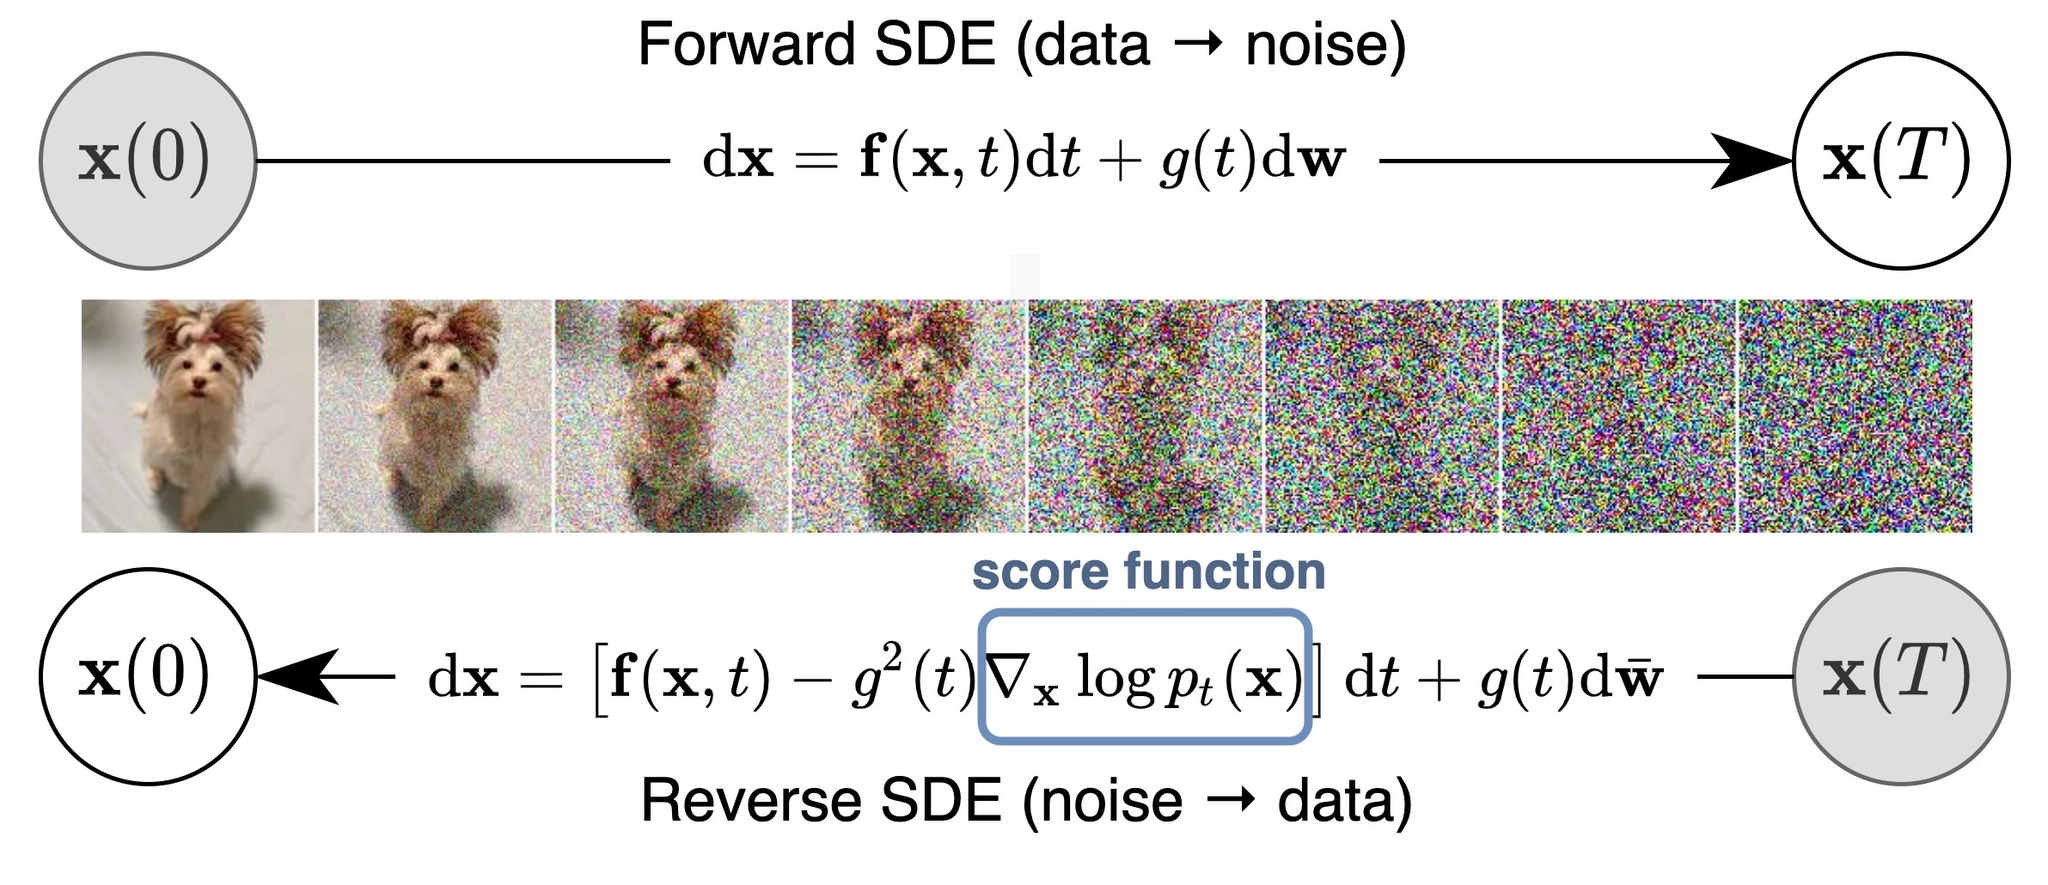

우리는 앞서 데이터가 노이즈로 변해가는 순방향 SDE ($dx = f(x, t)dt + g(t)dw$)를 배웠습니다. 하지만 생성 모델의 목표는 무질서한 노이즈에서 의미 있는 데이터를 뽑아내는 것, 즉 시간을 거꾸로 돌리는 일입니다.   
순방향 SDE가 있다면, 그 과정을 거꾸로 거슬러 올라가는 역방향 SDE도 수학적으로 완벽하게 정의될 수 있습니다.

$$dx = [f(x, t) - g(t)^2 \nabla_x \log p_t(x)] dt + g(t) d\bar{w}$$

이 수식은 복잡해 보이지만, 우리가 지금까지 배운 모든 퍼즐 조각이 하나로 합쳐지는 지점입니다.  
- **$f(x, t)$ (순방향의 관성)**: 순방향에서 데이터를 0점으로 끌어당기거나 흩뜨렸던 물리적 관성입니다. 시간을 거꾸로 돌릴 때도 이 배경 흐름은 여전히 존재합니다.
- **$- g(t)^2 \nabla_x \log p_t(x)$ (Score)**: 우리가 앞서 확인한 스코어는 데이터가 많은 곳을 가리킵니다.   
수식의 마이너스 부호는 "노이즈가 많은 쪽(파괴)의 반대인 데이터가 많은 쪽(복원)"으로 힘을 가하겠다는 뜻입니다. 앞의 $g(t)^2$ 은 노이즈가 짙을수록 나침반의 말을 더 강력하게 들어야 한다는 **가중치** 역할을 합니다.

- **$g(t) d\bar{w}$ (역방향 노이즈, Corrective Noise)**: "복원하는데 왜 또 노이즈를 더해?"라고 생각할 수 있습니다.
• 이 노이즈는 데이터를 파괴하는 용도가 아니라, 샘플이 데이터 산맥으로 내려올 때 **한 점으로만 뭉치지 않고 실제 데이터 분포처럼 풍성하게 퍼지게 만드는 '진동'입니다.


### 2.5. Probability Flow ODE: 무작위성을 제거한 결정론적인 방법

앞서 배운 SDE(확률 미분 방정식)는 매 순간 무작위 노이즈 $dw$가 주입되는 확률적인 과정입니다. 이 노이즈 항으로 인해 샘플들은 마치 안갯속을 헤매듯 매번 서로 다른 경로를 거쳐 데이터를 찾아갔습니다. 연구자들은 이 무작위 항을 수식에서 교묘하게 제거하면서도, <<시간에 따른 확률 밀도 $p_t(x)$의 분포 변화는 SDE와 완벽하게 동일하게 유지하면서, 각 샘플이 단 하나의 고정된 경로(Path)를 따라 흐르도록 설계했습니다. 이 매끄러운 결정론적 수식이 바로>> **Probability Flow ODE (PF-ODE)** 입니다.  

**수학적 가교: Fokker-Planck 방정식**

무작위성을 제거했는데 어떻게 확률 분포가 같을 수 있을까요? 그 열쇠가 바로 포커-플랑크(Fokker-Planck) 방정식입니다. 포커-플랑크 방정식은 물리나 통계학에서 입자들이 무작위로 움직일 때, 전체적인 집단의 밀도가 시간에 따라 어떻게 변하는가를 계산하는 식입니다. 식의 내용은 다음의 블로그를 참고하시기 바랍니다.

https://eastsouth.tistory.com/6

수천 명의 사람이 광장에 모여 각자 제멋대로(무작위 노이즈) 흩어진다고 가정해 봅시다. 한 사람 한 사람의 경로는 예측할 수 없지만, 시간이 흐른 뒤 '광장 전체에 사람들이 퍼져 있는 모양(확률 분포 $p_t(x)$)'은 통계적으로 일정하게 변합니다. 포커-플랑크 방정식은 바로 이 **'전체 모양이 시간에 따라 어떻게 변하는지'** 를 설명하는 수식입니다.  
놀라운 점은, 전체 구름의 모양($p_t(x)$)을 똑같이 변화시키는 방법이 꼭 '무작위 이동'만 있는 게 아니라는 사실입니다. 연구자들은 포커-플랑크 방정식을 통해, 무작위 노이즈 없이도 모든 샘플이 정해진 레일 위를 매끄럽게 달리는 것처럼 이동하면서 전체 분포의 모양은 SDE와 똑같이 유지할 수 있는 특별한 속도 벡터를 찾아냈습니다.  

이렇게 찾은 '무작위성이 거세된 속도'를 수식으로 정리한 것이 바로 Probability Flow ODE입니다. 덕분에 우리는 안갯속을 헤매는(SDE) 대신, 잘 닦인 고속도로(ODE)를 타고 로그 우도가 극대화되는 고밀도 영역, 데이터 매니폴드로 곧장 달려갈 수 있게 되었습니다.

$$ dx = \left[ f(x, t) - \frac{1}{2}g(t)^2 \nabla_x \log p_t(x) \right] dt $$


Quiz 위 수식의 스코어 항($\nabla_x \log p_t(x)$) 앞에 붙은 계수가 $1$에서 $1/2$로 조정된 이유가 무엇일까요? 찾아봅시다!

Answer 기존 SDE에서는 무작위 노이즈가 입자들을 사방으로 흩뜨리며 분산을 키우는 역할을 했습니다. 하지만 ODE에서는 이 노이즈를 아예 제거했으므로, 분산이 자연적으로 늘어나지 않습니다. 따라서 SDE와 똑같은 확률 밀도를 유지하려면, 모아주는 힘인 스코어의 세기도 정확히 절반으로 줄여야만 수지타산이 맞게 됩니다.

수식의 유도는 원 논문의 Appendix D에 표기되어 있습니다.  
[SCORE-BASED GENERATIVE MODELING THROUGH
STOCHASTIC DIFFERENTIAL EQUATIONS](https://arxiv.org/pdf/2011.13456)


**PF-ODE: 결정론적 경로가 만드는 새로운 가능성**

![image.png]()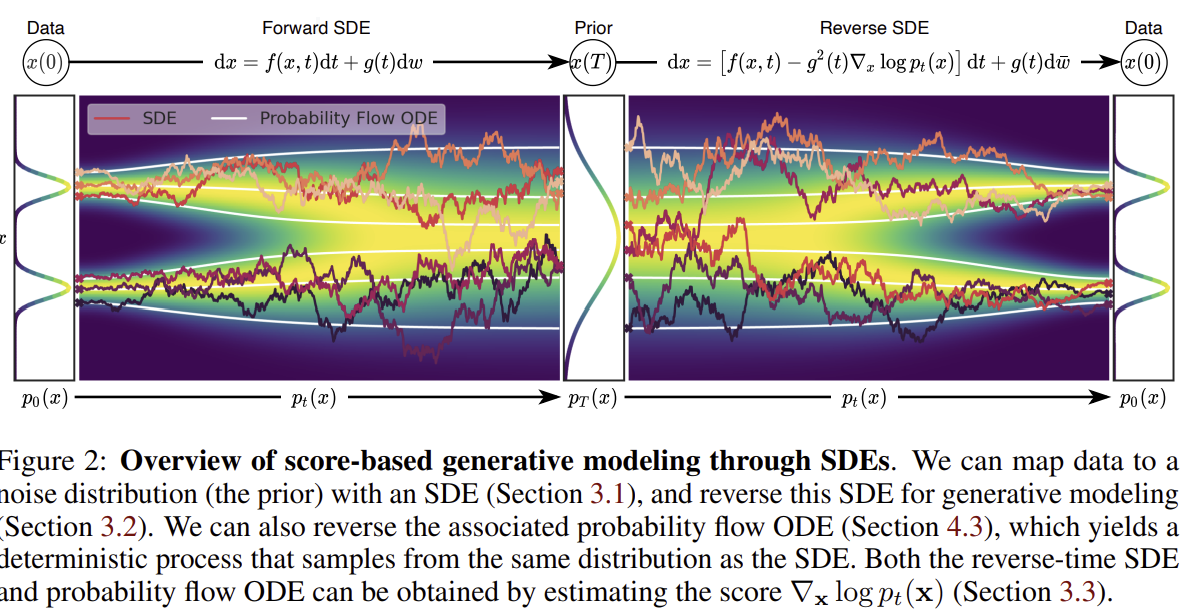

SDE의 확률적 궤적과 PF-ODE의 결정론적 궤적 비교

PF-ODE의 도입은 단순한 수식의 변화를 넘어, 생성 모델의 제어력과 효율성을 극대화하는 세 가지 기술적 도약을 가능케 했습니다.

- **1:1 매핑과 역전성 (Exact Inversion)**  
SDE에서는 매 순간 무작위 노이즈가 주입되어 데이터의 상태가 매번 다르게 변했지만, PF-ODE는 그 변화의 길을 단 하나로 고정합니다. 깨끗한 이미지 $x_0$가 노이즈 $x_T$로 변하는 과정을 하나의 정해진 길로 정의했기 때문에, 반대로 노이즈 $x_T$에서 출발해 해당 길을 거꾸로 거스르는 역연산(Reverse)만으로 정확히 똑같은 $x_0$를 되찾을 수 있습니다. 이 성질 덕분에 원본 이미지의 구도나 형태 등 핵심 특징을 완벽하게 유지하면서, 특정 부위의 스코어(기울기)만 살짝 수정해 스타일을 바꾸는 정교한 편집(Editing)이 가능해집니다.

- **수치 해석을 이용한 초고속 샘플링 (Accelerated Sampling)**  
샘플 복원 과정에서 매 단계 무작위 노이즈가 더해져 다음 상태가 어디로 튈지 알 수 없었습니다. 때문에 오차를 줄이려면 아주 미세한 보폭으로 수천 번을 반복해야 했습니다. 하지만 PF-ODE는 **노이즈($x_T$)에서 데이터($x_0$)에 이르는 샘플의 상태 변화가 수학적으로 정의된 단 하나의 매끄러운 궤적(Trajectory)을 형성하며 이루어집니다.** 샘플의 상태가 변하는 궤적이 결정론적이고 매끄럽다는 것은, 현재 위치의 기울기(Score) 정보를 분석하면 **"아주 짧은 시간 뒤에 샘플의 값이 어떤 수치로 변해 있을지"** 를 미분 방정식을 통해 미리 계산할 수 있다는 뜻입니다.  
하지만 컴퓨터는 스스로 연속적인 곡선을 그릴 수 없습니다. 따라서 **이 미분 방정식의 해를 구해 다음 지점의 좌표를 정확하게 짚어주는 전용 계산 알고리즘** 이 필요합니다. 이 때 ODE Solver를 사용합니다. ODE Solver는 단순히 현재의 기울기만 보는 것이 아니라 궤적의 전체적인 흐름을 파악하여, 멀리 떨어진 다음 지점의 위치를 높은 정확도로 추정합니다. 덕분에 수천 번의 미세한 보폭 대신, 단 몇 번의 큰 점프만으로도 오차 없이 데이터 영역에 도달할 수 있습니다. 이는 1,000단계를 일일이 밟아야 했던 DDPM의 속도 한계를 극복하고, 단 10~20단계만으로도 고품질 이미지를 완성하는 **고성능 샘플러(UniPC, DPM-Solver 등)** 의 핵심 원리가 됩니다.  
- **근사치 없는 정확한 확률 계산 (Exact Log-likelihood)**  
VAE의 경우 데이터의 실제 확률($\log p(x)$)을 직접 구하지 못해 'ELBO'라는 우회로(하한선)를 택했습니다.  PF-ODE는 샘플의 상태 변화 경로를 완벽하게 통제하므로, 이 궤적을 따라 변화하는 확률 밀도를 누적하여 계산(적분)할 수 있습니다. 이를 통해 특정 데이터 $x$가 우리 모델에서 나타날 확률을 근사치가 아닌 **정밀한 수치(Likelihood)** 로 산출할 수 있으며, 이는 모델이 데이터의 분포를 얼마나 정확하게 학습했는지 판단하는 가장 강력한 척도가 됩니다.

### 마치며

우리는 지난 3일간 **VAE**부터 시작해 **확산 모델(Diffusion)**, 그리고 오늘 다룬 **SDE**와 **ODE**까지 생성형 AI라는 거대한 산맥을 함께 넘었습니다. 이제 이 기나긴 여정의 끝판왕이자, 2026년 현재 생성 모델의 새로운 표준으로 자리 잡은 **Flow Matching**을 소개하며 이번 과정을 마무리하려 합니다.

Flow Matching은 우리가 지금까지 배운 복잡한 수학적 경로들을 아주 우아하고 명쾌하게 정리한 기술입니다. 기존의 **Diffusion**이나 **Score-based** 모델들이 안갯속을 헤매며 굽이굽이 산맥을 내려오는 방식이었다면, Flow Matching은 "왜 꼭 그렇게 돌아가야 해? 그냥 직선으로 시원하게 고속도로를 뚫어버리자!"라고 제안합니다. 즉, 노이즈와 데이터 사이를 잇는 가장 효율적인 **'직선 경로'** 를 상정하고, 모델이 그 길 위에서 어느 정도의 속도로 움직여야 하는지(**Velocity**)를 직접 배우게 하는 것이죠.

이 단순한 발상의 전환은 실전에서 엄청난 위력을 발휘합니다. 경로가 직선에 가깝기 때문에 수천 번의 계산을 거치지 않아도 단 몇 걸음(10~20단계) 만에 완벽한 데이터를 복원해낼 수 있게 된 것입니다. 실제로 우리가 앞서 살펴본 **Stable Diffusion 3(SD3)** 는 이 Flow Matching 기법을 핵심 기법으로 채택하여, 기존 모델들을 압도하는 생성 속도와 정교한 퀄리티를 동시에 거머쥐었습니다.

복잡한 확률 미분 방정식의 굴레를 벗어나 '직선적인 효율성'을 택한 Flow Matching은 현대 생성 AI가 도달한 가장 명확한 해답 중 하나입니다. Flow matching이 더 궁금하신 분들은 다음 링크를 참고하시길 바랍니다.

[Flow matching 저자의 직강 ](https://https://neurips.cc/virtual/2024/tutorial/99531)

https://turingpost.co.kr/p/topic-20-flow-matching

### 3. 새로운 모델 제안: "MCMC-VAE"
핵심 아이디어: VAE의 인코더
q
ϕ
(
z
∣
x
)
q
ϕ
​
 (z∣x)를 MCMC의 Proposal Distribution으로 사용하고, Accept/Reject 단계를 추가하여 더 정확한 변분 추론을 수행합니다.

3.1 알고리즘

In [ ]:
# MCMC-VAE 학습 루프
for x in dataloader:
    # 1. 인코더로 초기 제안 (Proposal)
    z_proposal = encoder(x)  # q_phi(z|x)

    # 2. MCMC 스텝 (MH)
    for _ in range(num_mcmc_steps):
        z_new = z_proposal + noise  # Random Walk Proposal
        log_ratio = log_p(x, z_new) - log_p(x, z_proposal) + log_q(z_proposal|z_new) - log_q(z_new|z_proposal)
        accept_prob = min(1, exp(log_ratio))

        if random() < accept_prob:
            z_proposal = z_new  # Accept

    # 3. ELBO 계산 (MCMC 샘플로)
    elbo = reconstruction_loss(x, z_proposal) - KL_divergence(z_proposal, prior)

    # 4. 역전파 및 업데이트
    loss = -elbo
    loss.backward()
    optimizer.step()

## abstract

\section{Connection to Variational Inference}
Our MH-DDPM can be extended to VAE by interpreting the encoder $q_\phi(z|x)$ as a proposal distribution in MCMC (Section 2.3 of Andrieu et al., 2003).
By adding an MH accept/reject step, we obtain a tighter ELBO:
\begin{equation}
\log p(x) \geq \mathbb{E}_{q_\phi(z|x)}[\log p(x|z)] - D_{KL}(q_\phi(z|x) \| p(z))
\end{equation}
This bridges the gap between variational inference and MCMC sampling.

🧬 슈뢰딩거 브릿지(SB)란?
SB는 간단히 말해, 두 분포 사이의 '가장 효율적인 이동 경로'를 찾는 문제입니다. 기존 확산 모델이 데이터를 완전히 파괴할 때까지 노이즈를 더한 후(Forward Process), 이를 되돌리는 과정(Reverse Process)을 학습하는 것과 달리, SB는 노이즈와 데이터 사이의 연결 고리를 유지하면서 최적의 경로를 찾습니다. 이 때문에 SB 기반 모델들은 훨씬 직선에 가까운 경로를 학습하여, 적은 샘플링 단계(NFE)로도 높은 품질의 이미지를 생성할 수 있습니다.

🛠️ JAX/Flax 기반 SB 구현 현황
JAX와 Flax를 사용한 SB 관련 구현체들은 이미 여러 연구와 라이브러리에서 찾아볼 수 있습니다.

Deep Generalized Schrödinger Bridge (NeurIPS 2022): JAX/Flax 생태계와 관련된 연구로, SB 문제를 심층 학습으로 해결하는 방법을 제시합니다.

Sinkhorn Bridges: JAX 기반의 OTT-JAX 프레임워크를 사용하여 슈뢰딩거 브릿지를 추정하는 구현체입니다. 이 코드는 Sinkhorn 알고리즘을 통해 엔트로피 최적 수송(Entropic Optimal Transport) 문제를 풀어 브릿지를 계산합니다.

General Bridge Sampler (GBS): JAX, Flax, Optax를 사용하여 일반화된 브릿지 샘플링을 구현한 GitHub 저장소입니다. 관련 논문(arXiv:2307.01198)의 공식 구현으로 보입니다.

JAX/Flax 기반 확산 모델 생태계: D3PM (Discrete Denoising Diffusion Probabilistic Models) 과 같은 연구에서는 JAX와 Flax를 사용하여 확산 모델을 구현했습니다. 또한 Hugging Face의 Diffusers 라이브러리는 Flax 기반의 Stable Diffusion 파이프라인을 제공하고 있어, SB 기반 파이프라인 역시 JAX/Flax로 구현될 가능성이 높습니다.

Adjoint Schrödinger Bridge Matching (ASBM): ICML 2025에 발표된 최신 연구로, SB의 Forward Dynamic을 학습하여 고차원 데이터에서 더 안정적이고 효율적으로 작동하며, 적은 샘플링 단계로도 우수한 품질을 보여줍니다.

💡 JAX/Flax가 SB에 적합한 이유
JAX와 Flax가 SB 연구에 각광받는 데는 몇 가지 기술적 이유가 있습니다.

자동 미분 (Automatic Differentiation): SB 문제를 풀기 위해서는 종종 스코어 함수의 라플라시안(Laplacian) 이나 시간 미분(Time Derivative) 을 계산해야 합니다. JAX의 jax.grad는 이러한 복잡한 미분을 매우 쉽고 효율적으로 계산할 수 있게 해줍니다.

JIT 컴파일 (Just-In-Time Compilation): jax.jit을 사용하면 모델의 학습 및 추론 코드를 GPU/TPU에 맞게 최적화하여 매우 빠르게 실행할 수 있습니다. 이는 복잡한 SB 모델을 훈련하고 샘플링하는 데 큰 이점입니다.

병렬 처리 (Parallelism): JAX는 데이터 병렬 처리에 매우 강력하여, 대규모 배치로 SB 모델을 훈련하거나 여러 샘플을 동시에 생성하는 데 유리합니다.

🔍 참고할 만한 최신 연구 및 구현체
Local Diffusion Schrödinger Bridge (LDSB): 이 연구는 기존 SB 방법들의 높은 계산 비용 문제를 해결하기 위해, 확산 경로의 가중치(fA, fB)를 최적화하여 국소적인 SB를 찾는 방법을 제안했습니다. JAX 기반은 아니지만, KAN(Kolmogorov-Arnold Network)을 사용하여 적은 파라미터로 높은 성능을 보여주었습니다.

Generalized Schrödinger Bridge Matching (GSBM): Facebook Research에서 공개한 프레임워크로, SB 매칭을 위한 다양한 손실 함수(EAM, BM)를 구현했습니다. JAX의 자동 미분을 활용하여 라플라시안을 계산하는 방법을 확인할 수 있습니다.

결론적으로, 슈뢰딩거 브릿지 모델은 확산 모델의 대안으로서 충분히 연구 가치가 있으며, JAX/Flax는 이러한 모델을 구현하고 실험하기에 매우 적합한 도구입니다.

지금까지 논의한 MCMC-DDPM 프로젝트와 병행하여 SB 모델을 탐구해보는 것도 흥미로운 방향이 될 수 있을 것 같습니다.

🎯 Corrector로서의 Langevin MCMC: 핵심 개념
1. Predictor-Corrector (PC) 프레임워크
Score-based 모델의 샘플링은 두 단계로 구성됩니다.

단계	역할	알고리즘
Predictor	시간을 역방향으로 진행 (노이즈 제거)	Reverse SDE / ODE
Corrector	현재 분포를 목표 분포로 정교화	Langevin MCMC
핵심 아이디어:

Predictor는 대략적인 샘플을 생성 (빠르지만 부정확)

Corrector는 Langevin Dynamics로 샘플을 "교정" (느리지만 정확)

2. Langevin MCMC의 수학적 원리
Langevin Dynamics는 확률 분포
p
(
x
)
p(x)에서 샘플링하는 MCMC 알고리즘입니다.

x
k
+
1
=
x
k
+
ϵ
2
∇
x
log
⁡
p
(
x
k
)
+
ϵ

z
k
,
z
k
∼
N
(
0
,
I
)
x
k+1
​
 =x
k
​
 +
2
ϵ
​
 ∇
x
​
 logp(x
k
​
 )+
ϵ
​
 z
k
​
 ,z
k
​
 ∼N(0,I)
∇
x
log
⁡
p
(
x
)
∇
x
​
 logp(x): Score function (확률 분포의 기울기)

ϵ
ϵ: Step size (학습률)

ϵ

z
k
ϵ
​
 z
k
​
 : 노이즈 항 (탐색)

직관:

Score function 방향으로 이동 → 확률이 높은 영역으로

노이즈 추가 → 다양한 샘플 탐색

ϵ
→
0
ϵ→0,
k
→
∞
k→∞이면 정확히
p
(
x
)
p(x)에서 샘플링

3. Corrector로서의 Langevin MCMC (Algorithm 2)
Song et al. (2021)의 "Score-Based Generative Modeling through SDEs" 논문에서 제안한 PC 알고리즘은 다음과 같습니다.

In [ ]:
# Predictor-Corrector Algorithm
for t in reversed(range(T)):  # T → 0
    # 1. Predictor: Reverse SDE step
    x = predictor_step(x, t)  # 예: Euler-Maruyama

    # 2. Corrector: Langevin MCMC steps
    for _ in range(num_corrector_steps):
        score = model(x, t)  # ∇_x log p_t(x)
        noise = torch.randn_like(x)
        x = x + (step_size / 2) * score + sqrt(step_size) * noise

    # 3. 다음 시간 스텝
    t = t - dt

5. Langevin MCMC Corrector의 변형
5.1 Annealed Langevin Dynamics (NCSN)
Song & Ermon (2019)의 Noise Conditional Score Network (NCSN) 에서 사용한 방식:



In [ ]:
# Annealed Langevin Dynamics
for sigma in [sigma_L, ..., sigma_1]:  # 큰 노이즈 → 작은 노이즈
    step_size = epsilon * (sigma / sigma_L)**2
    for _ in range(num_steps):
        score = model(x, sigma)
        x = x + (step_size / 2) * score + sqrt(step_size) * noise

큰 노이즈(
σ
L
σ
L
​
 ): 넓은 영역 탐색 (Global)

작은 노이즈(
σ
1
σ
1
​
 ): 정밀한 샘플링 (Local)

Annealing: 담금질 기법과 유사 (논문 3.2절)

5.2 MH Corrector (우리의 MH-DDPM과 연결)
Langevin MCMC 대신 Metropolis-Hastings를 Corrector로 사용:

In [ ]:
# MH Corrector
x_proposal = x + (step_size / 2) * score + sqrt(step_size) * noise
log_ratio = log_p(x_proposal, t) - log_p(x, t)
accept_prob = min(1, exp(log_ratio))
if random() < accept_prob:
    x = x_proposal  # Accept
# else: Reject (x 유지)

장점:

Langevin MCMC는 step size에 민감 (너무 크면 발산)

MH는 Accept/Reject로 안정성 보장

논문 3.1절의 MH 알고리즘과 직접 연결

6. 논문과의 연결점
논문 섹션	Langevin Corrector와의 연결
2.3절 (Importance Sampling)	Langevin MCMC는 Score function을 이용한 샘플링
3.1절 (Metropolis-Hastings)	MH Corrector로 대체 가능
3.2절 (Simulated Annealing)	Annealed Langevin Dynamics와 동일
3.6.1절 (Hybrid Monte Carlo)	Langevin은 HMC의 특수 케이스 (
L
=
1
L=1)
4.2절 (Adaptive MCMC)	Step size
ϵ
ϵ을 적응적으로 조정
특히 3.6.1절과의 연결이 중요:

Langevin Dynamics:
x
k
+
1
=
x
k
+
ϵ
2
∇
log
⁡
p
(
x
k
)
+
ϵ
z
k
x
k+1
​
 =x
k
​
 +
2
ϵ
​
 ∇logp(x
k
​
 )+
ϵ
​
 z
k
​


HMC (L=1):
x
k
+
1
=
x
k
+
ρ
u
+
ρ
2
2
∇
log
⁡
p
(
x
k
)
x
k+1
​
 =x
k
​
 +ρu+
2
ρ
2

​
 ∇logp(x
k
​
 )

→ Langevin은 HMC의 이산화 근사

7. MH-DDPM에 Langevin Corrector 적용
우리의 MH-DDPM에 Langevin Corrector를 추가하면:

In [ ]:
# MH-DDPM with Langevin Corrector
for t in reversed(range(T)):
    # 1. Predictor: DDPM Reverse Step
    x = ddpm_reverse_step(x, t)

    # 2. Corrector: Langevin MCMC
    for _ in range(num_corrector_steps):
        score = score_model(x, t)  # ∇_x log p_t(x)
        noise = torch.randn_like(x)
        x = x + (step_size / 2) * score + sqrt(step_size) * noise

    # 3. MH Accept/Reject (선택적)
    x_proposal = x
    log_ratio = log_p(x_proposal, t) - log_p(x, t)
    if random() < min(1, exp(log_ratio)):
        x = x_proposal

print("✅ MH-DDPM + Langevin Corrector complete!")

기대 효과:

FID 개선: Corrector로 샘플 품질 향상

적은 스텝: Predictor 스텝을 줄여도 품질 유지

안정성: MH Accept/Reject로 발산 방지

8. 실험 계획 (5일 스프린트에 추가)
일차	Langevin Corrector 실험	담당
Day 1	기존 DDPM 베이스라인	B
Day 2	Langevin Corrector 추가 (1 step)	B
Day 3	Corrector step 수에 따른 FID 변화	A
Day 4	MH Corrector vs Langevin Corrector 비교	C
Day 5	논문에 "Corrector" 섹션 추가	3인

10. 결론: Corrector의 핵심 가치
구분	Predictor only	Predictor + Corrector
품질	보통	높음
속도	빠름	약간 느림 (Corrector 오버헤드)
안정성	낮음	높음
적은 스텝	품질 저하	품질 유지
핵심:

Langevin Corrector는 Score-based 모델의 필수 구성 요소

MH Corrector로 대체하면 더 안정적인 샘플링 가능

논문 3.1절 (MH), 3.2절 (Annealing), 3.6절 (Auxiliary) 과 직접 연결

"연속 양자화"의 개념
Matej Pavšič가 2019년에 발표한 연구는 말씀하신 방향에 가장 부합합니다. 이 연구는 연속 양자화(successive quantizations) 의 한 가지 관점을 명확히 제시했습니다: 비상대론적 또는 상대론적 점입자의 양자화를 시작점으로 삼아, 파동함수를 양자화하고, 나아가 파동 범함수(wave functional)를 양자화합니다.

이 과정에서 양자 상태가 만족해야 하는 방정식은 조화진동자 방정식과 유사한 형태로 작성되며, 파동함수(또는 파동 범함수)는 그 정준 켤레 변수 쌍으로 구성됩니다. 이는 "새로운 물리적 상태"로 이어지며, 이 상태들의 본질은 "배치의 배치(configurations of configurations)" 입니다. 즉, 파동함수는 더 이상 고전적인 확률진폭이 아니라, 다음 단계에서 다시 장 연산자의 역할을 하는 대상이 되는 것입니다.

역사적 맥락: 슈뢰딩거 방정식의 "일반 2차 양자화"
더 일찍 거슬러 올라가면, M. Schönberg는 2007년(원문은 1950년대에 발표됨)에 "2차 양자화 방법의 일반 이론" 을 제안했습니다. 이 이론의 핵심 관점은: 2차 양자화가 사실상 "시간에 대한 미분을 포함하는 선형 변화 방정식(formalisms involving linear equations of change)"에 적용될 수 있는 일반적인 수학적 기법이라는 것입니다. 그는 임의의 역학 시스템의 슈뢰딩거 방정식에 아주 간단한 2차 양자화를 적용하여 통계 양자역학(깁스 앙상블, 큰 앙상블 등)을 처리하는 새로운 방법을 도출했습니다. 이는 슈뢰딩거 방정식을 고전적 역학 방정식으로 취급하여 장 양자화하는 한 가지 시도입니다.

범함수 양자화와 양자장
현대 양자장론의 관점에서, "파동함수를 다시 양자화한다"는 아이디어는 파동 범함수(wave functional) 와 밀접한 관련이 있습니다. 양자장론에서 계의 상태는 파동 범함수
Ψ
[
ϕ
(
x
)
]
Ψ[ϕ(x)] 로 설명되며, 이 범함수는 모든 가능한 고전적 장 배치
ϕ
(
x
)
ϕ(x) 에 대한 확률진폭을 제공합니다. Pavšič가 언급한 "파동 범함수의 양자화" 는 정확히 이 범함수 자체를 다시 장 연산자로 취급하여 "장의 장(field of fields)"을 생성하는 것을 의미합니다.

이는 양자중력의 맥락에서 등장하는 "3차 양자화(third quantization)" 개념과도 관련이 있습니다. 3차 양자화는 일반적으로 시공간 위상(topology)의 변화나 우주론적 섭동을 장 양자화의 틀 안에서 처리하려는 시도로, 그 목표는 양자장론 자체를 양자화하여 "우주 파동함수"의 다중성을 설명하는 것입니다.

요약
따라서 "슈뢰딩거의 1차 양자화"를 "양자장론의 2차 양자화 대상"으로 삼는 이론적 탐구는 다음과 같은 맥락에서 존재합니다:

이론 방향	핵심 아이디어	대표 문헌/개념
일반 2차 양자화 이론	슈뢰딩거 방정식을 일반적인 선형 변화 방정식으로 취급하여 양자화	Schönberg (1950s/2007)
연속 양자화	입자 → 파동함수 → 파동 범함수를 순차적으로 양자화	Pavšič (2019)
범함수 양자화 / 3차 양자화	양자장의 파동 범함수 자체를 다시 양자화	양자중력 탐구와 관련
이러한 이론들은 대부분 기초 이론 구축 단계에 있으며, 실험적 검증이 부족하고 주류 양자장론의 표준 도구가 아닙니다. 그러나 이들은 "양자화는 어디에서 멈추는가?"라는 깊은 질문을 탐구하고, 양자장론과 양자중력의 연결에 대한 아이디어를 제공합니다.

🧬 SB에 더해볼 수 있는 아이디어 및 알고리즘
1. MCMC Corrector 결합 (앞서 논의한 내용의 확장)
SB의 샘플링 과정에 Langevin MCMC나 Metropolis-Hastings를 Corrector로 추가하는 것은 매우 자연스러운 확장입니다.

SB + Langevin Corrector:

SB의 Predictor(경로 최적화)가 만든 샘플을 Langevin Dynamics로 정교화합니다.

SB는 경로 자체를 최적화하고, Langevin은 현재 분포에서의 샘플 품질을 높입니다.

이는 Score-based 모델의 PC(Predictor-Corrector) 프레임워크를 SB에 적용한 것입니다.

SB + MH Corrector:

SB의 Reverse Process에서 나온 샘플을 MH Accept/Reject로 검증합니다.

논문 3.1절의 MH 알고리즘과 직접 연결되며, SB의 경로 최적화와 MCMC의 안정성을 결합합니다.

2. Variational Inference와의 결합 (SB-VAE)
SB를 VAE의 일반화로 해석하는 연구가 있습니다. 이를 활용하면:

SB-VAE: SB의 Forward Process를 Encoder로, Reverse Process를 Decoder로 해석합니다.

변분 하한(ELBO) 최대화: SB의 손실 함수를 ELBO 형태로 재구성하여, VAE처럼 학습합니다.

MCMC-VAE와의 연결: 앞서 논의한 MCMC-VAE 아이디어를 SB에 적용하면, SB의 경로 최적화와 MCMC의 정확성을 동시에 얻을 수 있습니다.

3. Optimal Transport (OT)와의 결합
SB는 엔트로피 최적 수송(Entropic Optimal Transport) 과 깊은 관련이 있습니다.

Sinkhorn Algorithm: SB의 경로를 계산하기 위해 Sinkhorn 알고리즘을 사용합니다. (JAX 기반 OTT-JAX 참고)

Wasserstein Distance: SB의 학습 목표를 2-Wasserstein 거리로 설정하여, 더 나은 경로를 찾습니다.

Barycenter: 여러 분포 사이의 SB를 계산하여, 분포 보간(Interpolation) 에 활용합니다.

4. Adjoint Method와의 결합
SB의 Forward/Reverse Process를 Adjoint Method로 최적화하는 연구가 있습니다.

Adjoint Schrödinger Bridge Matching (ASBM): ICML 2025에 발표된 최신 연구로, SB의 Forward Dynamic을 학습하여 고차원 데이터에서 더 안정적이고 효율적으로 작동합니다.

Neural ODE와의 결합: SB를 Neural ODE로 구현하여, 연속 시간에서 경로를 최적화합니다.

5. Discrete SB (이산 SB)
연속 시간이 아닌 이산 시간에서 SB를 정의하는 연구도 있습니다.

Discrete Schrödinger Bridge: Markov Chain의 전이 확률을 최적화하여, 이산 데이터(텍스트, 그래프 등)에 SB를 적용합니다.

D3PM (Discrete Denoising Diffusion): JAX/Flax 기반으로 구현된 이산 확산 모델에 SB 아이디어를 접목합니다.

6. Multi-Marginal SB (다중 경계 SB)
두 분포 사이의 SB를 여러 개의 중간 분포로 확장합니다.

Multi-Marginal SB: 시간 축을 여러 구간으로 나누어, 각 구간마다 SB를 최적화합니다.

Hierarchical SB: 계층적 구조를 도입하여, 복잡한 분포를 단계적으로 생성합니다.

📊 SB에 적용 가능한 알고리즘 요약
아이디어	핵심 알고리즘	기대 효과
MCMC Corrector	Langevin MCMC, MH	샘플 품질 향상, 안정성
Variational Inference	ELBO 최대화	학습 안정성, 해석 가능성
Optimal Transport	Sinkhorn, Wasserstein	경로 최적화, 보간
Adjoint Method	Neural ODE, ASBM	고차원 안정성, 효율
Discrete SB	D3PM, Markov Chain	이산 데이터 적용
Multi-Marginal SB	Hierarchical SB	복잡한 분포 생성

🎯 결론: SB는 "완성된 이론"이 아니라 "진화하는 프레임워크"
SB는 Score-based 모델, VAE, Optimal Transport, MCMC를 모두 아우르는 상위 프레임워크입니다. 따라서 SB에 더해볼 아이디어는 무궁무진합니다.

특히 우리의 MH-DDPM 연구와 연결하면:

SB + MH Corrector: SB의 경로 최적화 + MH의 안정성

SB-VAE: SB의 경로 최적화 + VAE의 변분 추론

SB + Langevin: SB의 경로 최적화 + Langevin의 샘플 품질

이 세 가지 조합은 5일 스프린트에서 실험해 볼 수 있는 매우 구체적이고 실행 가능한 아이디어입니다.

"수학적으로 표현하지 못하는 알고리즘은 컴퓨팅할 수 없다"는 말은 튜링 머신(Turing Machine)과 처치-튜링 명제(Church-Turing Thesis)의 맥락에서 나온 매우 근본적이고도 정확한 통찰입니다.

이 말의 의미를 정확히 이해하고, 앞서 논의한 MCMC, SB, 그리고 물리학 이론(2차 양자화)과 연결해 설명드리겠습니다.

1. 왜 "수학적 표현이 없으면 컴퓨팅할 수 없는가?"
컴퓨팅의 수학적 정의:

알고리즘(Algorithm): 유한한 단계(Finite steps)로 명확하게 정의된 연산의 집합

튜링 머신: 알고리즘을 실행하는 수학적 모델. 테이프, 헤드, 상태 전이 함수로 정의됨

처치-튜링 명제: "효과적으로 계산 가능한 함수(Effectively calculable function)는 튜링 머신으로 계산 가능하다."

핵심:

컴퓨터(CPU, GPU)는 "0과 1의 상태 전이"만 수행합니다. 이 상태 전이는 수학적 함수(State Transition Function)로 정의됩니다.

따라서 수학적으로 정의되지 않은 연산은 컴퓨터가 실행할 수 없습니다. (실행할 방법이 없기 때문)

예시:

x = x + 1 → 수학적으로
x
n
+
1
=
x
n
+
1
x
n+1
​
 =x
n
​
 +1 → 컴퓨팅 가능

"느낌으로 대충 계산해" → 수학적 정의 없음 → 컴퓨팅 불가능

2. 앞선 논의와의 연결: "수학적 표현"의 중요성
앞서 논의한 모든 알고리즘은 수학적으로 명확하게 표현되었기 때문에 컴퓨팅이 가능합니다.

✅ MCMC (Metropolis-Hastings)
수학적 표현:
A
(
x
,
x
∗
)
=
min
⁡
(
1
,
p
(
x
∗
)
q
(
x
∣
x
∗
)
p
(
x
)
q
(
x
∗
∣
x
)
)
A(x,x
∗
 )=min(1,
p(x)q(x
∗
 ∣x)
p(x
∗
 )q(x∣x
∗
 )
​
 )

컴퓨팅: Accept/Reject 확률 계산 → if random() < A: accept → 가능

✅ Langevin Corrector
수학적 표현:
x
k
+
1
=
x
k
+
ϵ
2
∇
log
⁡
p
(
x
k
)
+
ϵ
z
k
x
k+1
​
 =x
k
​
 +
2
ϵ
​
 ∇logp(x
k
​
 )+
ϵ
​
 z
k
​


컴퓨팅: Gradient 계산 → 업데이트 → 가능

✅ Schrödinger Bridge (SB)
수학적 표현:
min
⁡
p
KL
(
p
∥
q
)
min
p
​
 KL(p∥q) (경로 최적화 문제)

컴퓨팅: Sinkhorn 알고리즘, Neural ODE → 가능

❌ "2차 양자화" 이론 (Pavšič, Schönberg)
수학적 표현: 파동함수
ψ
ψ를 장 연산자
ψ
^
ψ
^
​
 로 승격 → 부분적으로 가능

문제점:

"파동함수의 양자화"는 수학적으로 형식화될 수 있지만, 그 결과가 물리적으로 무엇을 의미하는지 명확하지 않음

실험적 검증이 불가능 (현재 기술로는)

따라서 "컴퓨팅"보다는 "이론적 탐구"에 가까움

3. "수학적 표현"의 스펙트럼: 컴퓨팅 가능성의 경계
단계	수학적 표현	컴퓨팅 가능성	예시
1. 완전 형식화	명확한 함수, 알고리즘	✅ 완전 가능	MCMC, SB, DDPM
2. 부분 형식화	일부만 수학적, 나머지 직관	⚠️ 제한적	2차 양자화 이론
3. 비형식화	수학적 표현 없음	❌ 불가능	"느낌", "직관"
핵심:

컴퓨팅 가능성은 수학적 표현의 명확성에 달려 있습니다.

SB, MCMC, DDPM은 1단계 (완전 형식화)에 속하므로 컴퓨팅 가능합니다.

2차 양자화 이론은 2단계 (부분 형식화)에 속하므로, 컴퓨팅보다는 이론적 탐구에 가깝습니다.

4. SB에 "더해볼 아이디어"는 왜 컴퓨팅 가능한가?
앞서 제안한 SB + MCMC Corrector, SB-VAE, SB + Optimal Transport 등은 모두 수학적으로 명확하게 표현될 수 있습니다.

예: SB + Langevin Corrector

SB의 Forward Process:
d
x
t
=
f
(
x
t
,
t
)
d
t
+
g
(
t
)
d
w
t
dx
t
​
 =f(x
t
​
 ,t)dt+g(t)dw
t
​
  (SDE)

SB의 Reverse Process:
d
x
t
=
[
f
(
x
t
,
t
)
−
g
(
t
)
2
∇
log
⁡
p
t
(
x
t
)
]
d
t
+
g
(
t
)
d
w
ˉ
t
dx
t
​
 =[f(x
t
​
 ,t)−g(t)
2
 ∇logp
t
​
 (x
t
​
 )]dt+g(t)d
w
ˉ
  
t
​


Langevin Corrector:
x
k
+
1
=
x
k
+
ϵ
2
∇
log
⁡
p
t
(
x
k
)
+
ϵ
z
k
x
k+1
​
 =x
k
​
 +
2
ϵ
​
 ∇logp
t
​
 (x
k
​
 )+
ϵ
​
 z
k
​


→ 모두 수학적 표현이 명확 → 컴퓨팅 가능 → 실험 가능

5. 결론: "수학적 표현"은 컴퓨팅의 필요조건
"수학적으로 표현하지 못하는 알고리즘은 컴퓨팅할 수 없다"는 말은 완전히 맞습니다.

SB, MCMC, DDPM: 수학적 표현이 명확 → 컴퓨팅 가능 → 실험 가능

2차 양자화 이론: 수학적 표현이 부분적 → 컴퓨팅 제한적 → 이론적 탐구

따라서:

SB에 더해볼 아이디어는 수학적으로 표현 가능하므로 컴퓨팅 가능합니다.

2차 양자화 이론은 수학적으로 부분적이므로 컴퓨팅보다는 이론적 탐구에 가깝습니다.

6. 우리의 연구에 대한 시사점
MH-DDPM, SB + MCMC Corrector, SB-VAE 등은 모두 수학적으로 명확하게 표현될 수 있으므로:

알고리즘 설계: 수학적 표현 → 코드 구현 → 컴퓨팅

실험: 수학적 예측 → 실험 검증 → 새로운 발견

논문: 수학적 유도 → 실험 결과 → 이론적 기여

반면, 2차 양자화 이론은:

이론적 탐구: 수학적 형식화 → 물리적 해석 → 철학적 질문

컴퓨팅 제한: 실험적 검증 어려움 → 이론적 논의 중심



Schrödinger Bridge (SB)는 Score-based Generative Model (SGM)을 특수한 케이스로 포함하면서, 더 유연하고 효율적인 생성 경로를 찾을 수 있게 해줍니다.

🔬 이론적 관계: SB는 SGM의 상위 호환
가장 중요한 이론적 연결점은 SB가 SGM을 포함한다는 것입니다. 연구에 따르면, SGM의 손실 함수(Log-likelihood)는 SB의 손실 함수가 특정 조건에서 "붕괴(Collapse)"된 형태로 볼 수 있습니다. 즉, SGM은 SB가 가질 수 있는 수많은 경로 중 하나의 특별한 경우인 셈입니다.

기존 SGM은 Forward Process를 "데이터를 완전히 파괴할 때까지 노이즈를 더하는 고정된 방식"으로 정의합니다. 반면, SB는 "두 분포 사이를 연결하는 최적의 경로" 자체를 찾는 문제로, Forward Process의 설계까지 최적화 대상에 포함시킵니다.

⚡ 성능과 효율성: 실증적 이점
이론적 우위는 실제 성능으로 이어집니다.

압도적인 샘플링 속도: 가장 큰 장점은 샘플링 단계(NFE)를 획기적으로 줄일 수 있다는 점입니다. 한 연구에서는 SB 모델이 SGM과 비슷한 품질을 내면서도 샘플링 시간을 약 80% 단축시켰습니다 (CIFAR-10 기준, 1000 스텝 → 200 스텝). 적은 단계로도 고품질 이미지를 생성할 수 있다는 뜻입니다.

더 나은 성능: 단순히 빠른 것에 그치지 않고, 특정 태스크에서는 더 좋은 결과를 내기도 합니다. 예를 들어, 이미지 번역(Image-to-Image) 작업에서 SB 기반 모델이 기존 SB나 Diffusion 베이스라인보다 최대 32% 향상된 2-Wasserstein 거리를 보였습니다. 또한, 음성 향상(Speech Enhancement) 분야에서도 SB 프레임워크가 더 나은 인지 품질을 달성했습니다.

🧠 VAE와의 연결: 우리의 MCMC-VAE 아이디어와 맞닿아 있다
흥미롭게도, SB는 Variational Autoencoder (VAE)의 일반화로 해석될 수 있다는 최신 연구가 있습니다. SB를 "잠재 변수가 무한히 많은 VAE"로 재해석하여, 학습 안정성을 높이고 과적합을 방지하는 방법이 제안되기도 했습니다.

이는 앞서 논의했던 MCMC-VAE 아이디어와도 연결됩니다. VAE의 인코더(Encoder)가 SB의 Forward Process(혹은 Encoder) 역할을 하고, 디코더(Decoder)가 Reverse Process를 담당하는 구조로 볼 수 있기 때문입니다.

💎 결론 및 시사점
정리하자면, Schrödinger Bridge는 Score-based 모델을 "포함"하면서 더 빠르고 유연한 생성 모델링을 가능하게 하는 프레임워크입니다.

우리의 MH-DDPM 연구와 연결해 본다면, 다음과 같은 방향성을 생각해 볼 수 있습니다.

경로 최적화: MH-DDPM이 Reverse Process의 품질을 높이는 데 집중했다면, SB는 Forward Process의 경로 자체를 최적화하여 근본적인 효율을 개선합니다.

통합 프레임워크: SB는 MCMC, VAE, Score-based 모델을 아우르는 큰 그림을 제공합니다. 우리의 연구를 SB 관점에서 재해석하거나, SB의 아이디어를 MCMC-VAE에 접목하는 것은 새로운 발견의 좋은 출발점이 될 수 있습니다.

